In [1]:
# Load packages
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import scipy.stats as scs

from FDApy import DenseFunctionalData, MultivariateFunctionalData
from FDApy.representation import DenseArgvals, DenseValues
from FDApy.preprocessing import MFPCA
from FDApy.visualization import plot, plot_multivariate

from nba import NbaScraper, ShotCharts

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r'\usepackage{amsfonts}'
})

COLORS = {
    'Guard': '#648FFF',
    'Forward-Guard': '#785EF0',
    'Forward': '#DC267F',
    'Forward-Center': '#FE6100',
    'Center': '#FFB000'
}


In [2]:
# Load data
with open('./data/players_shots_density.pickle', 'rb') as f:
    players_shots_density = pickle.load(f)
with open('./data/players_shots_density_made.pickle', 'rb') as f:
    players_shots_density_made = pickle.load(f)
with open('./data/player_position.pickle', 'rb') as f:
    players_position = pickle.load(f)

# Load MFPCA results
with open('./data/MFPCA.pickle', 'rb') as f:
    mfpca = pickle.load(f)
with open('./data/scores.pickle', 'rb') as f:
    scores = pickle.load(f)
with open('./data/MFPCA_reconstruction.pickle', 'rb') as f:
    fdata_reconstruction = pickle.load(f)

# Load clustering results
with open('./data/clustering.pickle', 'rb') as f:
    clustering = pickle.load(f)

In [3]:
# Reshape scores
scores = pd.DataFrame(scores)
scores.insert(loc=0, column='PLAYER_ID', value=players_shots_density.PLAYER_ID.values)
scores.insert(loc=0, column='PLAYER_NAME', value=players_shots_density.PLAYER_NAME.values)
scores = scores.join(players_position.set_index('PLAYER_ID'), how='left', on='PLAYER_ID', rsuffix='_')
scores['cluster'] = clustering['pred']

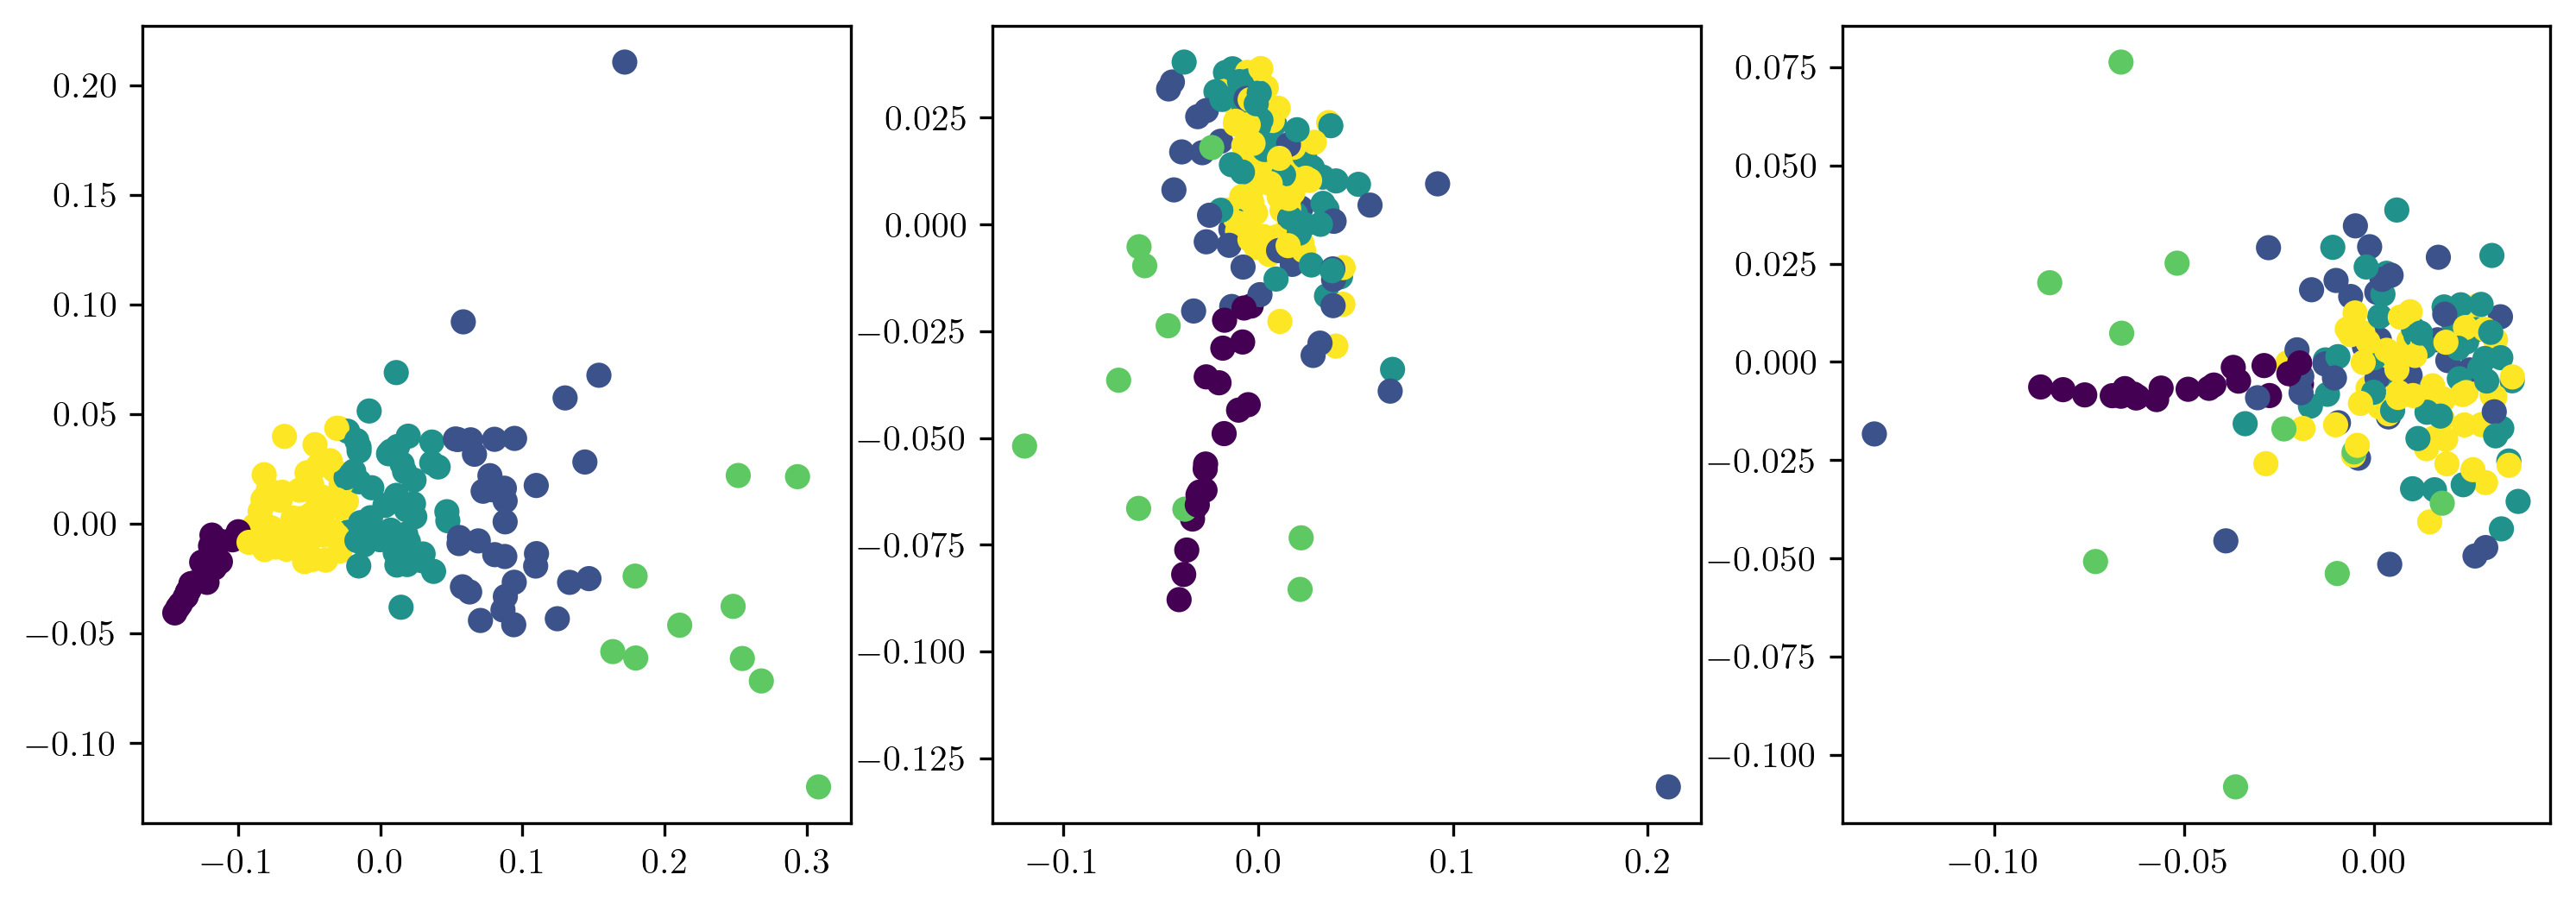

In [4]:
fig, ax = plt.subplots(
    1, 3,
    figsize=(12, 4),
    facecolor='white',
    edgecolor='black',
    dpi=300
)

ax[0].scatter(scores[0], scores[1], c=clustering['pred'])
ax[1].scatter(scores[1], scores[2], c=clustering['pred'])
ax[2].scatter(scores[2], scores[3], c=clustering['pred'])

plt.show()

In [5]:
scores.query('cluster == 0')

,PLAYER_NAME,PLAYER_ID,0,1,2,3,4,5,6,7,...,14,15,16,17,18,19,PLAYER_NAME_,POSITION,POSITION_,cluster
0,Bam Adebayo,1628389,-0.118237,-0.005185,-0.042209,-0.005885,0.018949,0.012929,-0.003376,-0.000571,...,-0.001201,-0.000133,0.002018,-0.000873,-0.002384,-0.001097,Bam Adebayo,Center-Forward,Forward-Center,0
2,Jarrett Allen,1628386,-0.134341,-0.030261,-0.062693,-0.009176,0.012630,0.014095,-0.001018,-0.004473,...,0.000560,-0.001498,0.002162,-0.001264,-0.000676,-0.001163,Jarrett Allen,Center,Center,0
4,Giannis Antetokounmpo,203507,-0.116491,-0.020181,-0.037082,-0.001397,0.021000,-0.000912,0.000790,-0.002391,...,0.000216,0.000554,-0.001289,0.000054,-0.003799,-0.004530,Giannis Antetokounmpo,Forward,Forward,0
6,Deandre Ayton,1629028,-0.119233,-0.010135,-0.043481,-0.006722,0.018533,0.007291,-0.001132,-0.001558,...,0.002468,-0.002451,0.004293,-0.000818,-0.004541,-0.002029,Deandre Ayton,Center,Center,0
29,Clint Capela,203991,-0.142232,-0.038316,-0.081964,-0.007063,-0.007060,0.020635,-0.004347,-0.006115,...,0.001607,-0.002981,0.002485,-0.004211,0.004965,0.001002,Clint Capela,Center,Center,0
31,Brandon Clarke,1629634,-0.112158,-0.008053,-0.027527,-0.008556,0.024442,0.008960,-0.000380,-0.001640,...,0.003967,0.004435,0.000190,0.003887,-0.000914,0.003026,Brandon Clarke,Forward,Forward,0
33,Nic Claxton,1629651,-0.136457,-0.033051,-0.066702,-0.008730,0.008688,0.015251,-0.002776,-0.003803,...,0.001597,-0.001618,0.002515,-0.001948,0.001251,0.000420,Nic Claxton,Center,Center,0
41,Anthony Davis,203076,-0.099734,-0.003668,-0.019104,-0.005620,0.023622,-0.004036,-0.003859,0.004971,...,-0.001101,0.000991,-0.000969,-0.000158,-0.002482,0.000316,Anthony Davis,Forward-Center,Forward-Center,0
47,Andre Drummond,203083,-0.136336,-0.033119,-0.066733,-0.008341,0.008173,0.015398,-0.001883,-0.004807,...,0.002403,-0.001960,0.003030,-0.001814,0.000428,-0.000348,Andre Drummond,Center,Center,0
54,Daniel Gafford,1629655,-0.137294,-0.033783,-0.068983,-0.008598,0.004573,0.016171,-0.001227,-0.005521,...,-0.000871,-0.001962,0.001665,-0.002450,0.002719,-0.000639,Daniel Gafford,Forward-Center,Forward-Center,0


In [6]:
scores.query('cluster == 1')

,PLAYER_NAME,PLAYER_ID,0,1,2,3,4,5,6,7,...,14,15,16,17,18,19,PLAYER_NAME_,POSITION,POSITION_,cluster
1,Grayson Allen,1628960,0.109311,-0.019301,0.019488,0.000346,0.015316,0.016513,-0.030221,-0.033596,...,-0.000868,-0.008437,-0.000192,-0.003327,-0.003439,0.002853,Grayson Allen,Guard,Guard,1
11,Malik Beasley,1627736,0.133185,-0.026743,-0.004059,-0.024497,0.014161,0.012537,0.006520,-0.010504,...,0.000497,0.004266,-0.009411,0.004001,0.002137,-0.005392,Malik Beasley,Guard,Guard,1
13,Bogdan Bogdanović,203992,0.109725,0.017435,-0.009346,-0.015480,0.015710,0.018837,-0.018284,-0.000278,...,0.015659,0.010956,-0.004674,-0.004341,-0.001985,-0.009859,Bogdan Bogdanović,Guard,Guard,1
26,Alec Burks,202692,0.077166,0.021913,0.003835,-0.013990,0.010486,0.005031,0.006319,-0.005964,...,0.003091,-0.011781,0.005774,0.010938,-0.001904,-0.008225,Alec Burks,Guard,Guard,1
28,Kentavious Caldwell-Pope,203484,0.055433,-0.009058,0.004172,-0.051509,0.008851,-0.012656,-0.004401,0.017607,...,-0.008252,-0.008388,0.002021,-0.008163,-0.000118,-0.002353,Kentavious Caldwell-Pope,Guard,Guard,1
35,Mike Conley,201144,0.094497,0.038906,0.000760,0.017739,0.020641,0.039686,-0.014860,0.031671,...,0.006120,0.003548,-0.002626,0.002415,0.000863,-0.005801,Mike Conley,Guard,Guard,1
36,Pat Connaughton,1626192,0.070500,-0.044127,0.033365,0.011494,0.016663,-0.001038,0.014130,-0.010691,...,-0.008536,0.008199,0.008963,-0.017649,0.002790,-0.001789,Pat Connaughton,Guard,Guard,1
37,Robert Covington,203496,0.086340,-0.039332,0.016989,0.026642,0.021618,0.003732,0.019395,-0.001440,...,0.006316,-0.006086,-0.004871,-0.004955,0.001686,-0.002600,Robert Covington,Forward,Forward,1
40,Stephen Curry,201939,0.080557,-0.014114,-0.001126,0.029327,0.020994,0.013922,0.015105,-0.009118,...,-0.013227,-0.006248,0.002174,-0.003409,0.005602,-0.005333,Stephen Curry,Guard,Guard,1
43,Donte DiVincenzo,1628978,0.062920,-0.031117,0.025241,-0.002035,0.015402,0.006176,0.000154,-0.004899,...,0.008235,-0.004987,0.005755,0.000705,-0.001215,-0.002418,Donte DiVincenzo,Guard,Guard,1


In [7]:
scores.query('cluster == 2')

,PLAYER_NAME,PLAYER_ID,0,1,2,3,4,5,6,7,...,14,15,16,17,18,19,PLAYER_NAME_,POSITION,POSITION_,cluster
8,Harrison Barnes,203084,-0.022757,-0.003905,0.033715,-0.016902,0.015882,0.008345,0.002962,-0.000937,...,-0.007975,-0.000153,0.001315,0.003395,-0.001729,0.000151,Harrison Barnes,Forward,Forward,2
12,Saddiq Bey,1630180,0.029349,-0.016871,0.035572,-0.025216,0.011207,-0.000162,-0.019603,-0.023661,...,-0.000926,-0.002415,0.004362,0.002055,0.004477,0.001174,Saddiq Bey,Guard-Forward,Forward-Guard,2
14,Bojan Bogdanović,202711,0.003379,0.008346,0.023545,-0.031255,0.011530,0.016655,0.012455,-0.003211,...,-0.006894,0.010504,0.001393,0.004138,0.002109,-0.005389,Bojan Bogdanović,Forward,Forward,2
15,Devin Booker,1626164,-0.014835,0.035024,-0.016742,-0.011246,0.021911,-0.011882,-0.002037,0.003148,...,0.000776,0.006669,-0.005183,0.001178,-0.003635,0.003132,Devin Booker,Guard,Guard,2
20,Dillon Brooks,1628415,0.012261,0.035233,0.003610,-0.002935,0.016217,0.007485,-0.005321,-0.001811,...,0.002040,0.000158,-0.008521,0.000158,0.003043,0.000745,Dillon Brooks,Guard-Forward,Forward-Guard,2
23,Jalen Brunson,1628973,-0.007722,0.051416,0.009393,-0.004662,0.018969,0.021305,-0.023586,0.026901,...,0.001469,-0.001252,0.003901,-0.005511,0.001076,0.002194,Jalen Brunson,Guard,Guard,2
32,Jordan Clarkson,203903,0.036394,0.037243,0.023127,0.006101,0.014677,0.038090,-0.002548,-0.021651,...,0.006657,-0.006294,-0.008689,-0.004226,-0.004438,0.002104,Jordan Clarkson,Guard,Guard,2
44,Spencer Dinwiddie,203915,-0.006766,0.002737,0.027902,-0.001614,0.014795,0.008123,0.012953,-0.004925,...,0.001236,0.003660,-0.001603,-0.003254,-0.000029,-0.005204,Spencer Dinwiddie,Guard,Guard,2
45,Luka Dončić,1629029,-0.014775,0.019141,0.002383,0.017237,0.022728,0.007941,0.001687,-0.021413,...,-0.002136,0.006628,-0.007280,-0.001647,0.000002,-0.003071,Luka Dončić,Forward-Guard,Forward-Guard,2
46,Luguentz Dort,1629652,0.010590,-0.013217,0.036457,-0.004801,0.013509,0.005934,0.006356,0.008377,...,0.008471,-0.004912,0.006865,0.000775,-0.002503,-0.003860,Luguentz Dort,Guard,Guard,2


In [8]:
scores.query('cluster == 3')

,PLAYER_NAME,PLAYER_ID,0,1,2,3,4,5,6,7,...,14,15,16,17,18,19,PLAYER_NAME_,POSITION,POSITION_,cluster
25,Reggie Bullock Jr.,203493,0.267959,-0.071711,-0.036478,-0.108167,-0.003455,0.003159,-0.006432,0.011802,...,-0.007532,-0.019189,-0.005571,0.000094,0.010982,-0.001008,Reggie Bullock Jr.,Guard-Forward,Forward-Guard,3
38,Jae Crowder,203109,0.179663,-0.061243,-0.005216,-0.022910,0.016798,0.002320,0.001391,-0.006168,...,0.005975,0.003304,-0.016114,-0.011157,0.001670,0.001081,Jae Crowder,Forward,Forward,3
39,Seth Curry,203552,0.251740,0.021996,-0.073392,-0.050810,-0.000104,-0.000592,0.056489,0.030781,...,0.014852,0.009004,0.019267,-0.003300,0.010953,0.010310,Seth Curry,Guard,Guard,3
62,Devonte' Graham,1628984,0.248135,-0.037699,-0.066680,0.076326,0.043787,0.000935,0.009428,0.022940,...,-0.022566,-0.009148,0.000208,0.014341,-0.003988,0.004774,Devonte' Graham,Guard,Guard,3
78,Justin Holiday,203200,0.163551,-0.058322,-0.009667,-0.053855,0.009381,-0.019979,0.010830,-0.001709,...,-0.002861,0.001070,0.005808,-0.004003,0.001523,-0.006694,Justin Holiday,Forward-Guard,Forward-Guard,3
93,Luke Kennard,1628379,0.293405,0.021457,-0.085467,0.020163,0.022905,0.002176,-0.001095,0.004938,...,-0.014012,0.013357,0.011352,-0.001136,-0.007324,-0.000594,Luke Kennard,Guard,Guard,3
110,Patty Mills,201988,0.254621,-0.061462,-0.066500,0.007306,0.034545,-0.057289,-0.009856,-0.012845,...,0.008223,-0.008277,-0.005281,-0.007520,-0.012830,0.006797,Patty Mills,Guard,Guard,3
119,Georges Niang,1627777,0.179239,-0.023896,0.018019,-0.035961,0.004181,0.043686,-0.015813,-0.024678,...,-0.001116,-0.002054,-0.000266,0.001951,-0.006467,0.001641,Georges Niang,Forward,Forward,3
139,Duncan Robinson,1629130,0.308197,-0.120013,-0.051897,0.025138,0.032246,0.027716,0.016010,-0.009107,...,0.001410,0.019208,-0.011659,0.006394,0.002232,0.005556,Duncan Robinson,Forward,Forward,3
148,Landry Shamet,1629013,0.210576,-0.046284,-0.023723,-0.017051,0.014865,0.001250,0.001834,-0.004701,...,-0.003585,0.009860,0.013717,0.011262,0.002568,-0.001074,Landry Shamet,Guard,Guard,3


In [9]:
scores.query('cluster == 4')

,PLAYER_NAME,PLAYER_ID,0,1,2,3,4,5,6,7,...,14,15,16,17,18,19,PLAYER_NAME_,POSITION,POSITION_,cluster
3,Kyle Anderson,203937,-0.045806,0.036065,0.023865,-0.016046,0.016540,0.024558,-0.003540,-0.005171,...,-0.002650,-0.003728,0.003765,0.000998,7.076191e-04,0.006123,Kyle Anderson,Forward-Guard,Forward-Guard,4
5,OG Anunoby,1628384,-0.038310,-0.016608,0.029432,-0.030721,0.016996,-0.008882,-0.000029,0.000679,...,-0.003476,0.003962,0.001963,0.003416,2.467985e-03,0.003233,OG Anunoby,Forward-Guard,Forward-Guard,4
7,Marvin Bagley III,1628963,-0.092868,-0.005276,0.001188,-0.004700,0.024295,-0.001502,-0.006575,0.009111,...,0.000910,-0.002779,0.001254,0.001583,-5.362655e-03,0.005728,Marvin Bagley III,Forward,Forward,4
9,RJ Barrett,1629628,-0.065835,-0.004651,0.014740,-0.009437,0.023752,0.000515,-0.003305,0.014392,...,0.000978,-0.000085,0.000013,0.000676,1.056393e-04,0.001865,RJ Barrett,Forward-Guard,Forward-Guard,4
10,Bradley Beal,203078,-0.040935,0.012170,0.003300,-0.010710,0.019502,-0.009432,0.000890,0.000086,...,-0.004904,0.001287,-0.001769,-0.002427,4.492013e-04,-0.002058,Bradley Beal,Guard,Guard,4
16,Chris Boucher,1628449,-0.053149,-0.017280,0.031164,-0.008479,0.017781,-0.010270,0.013400,-0.000242,...,0.008628,0.004577,-0.000316,0.000731,-1.390050e-03,0.001285,Chris Boucher,Forward,Forward,4
17,Mikal Bridges,1628969,-0.023711,0.010214,0.014724,-0.040727,0.017574,0.006120,-0.004190,0.005002,...,0.001042,0.011379,-0.004240,0.003893,3.185759e-03,0.003467,Mikal Bridges,Guard-Forward,Forward-Guard,4
18,Miles Bridges,1628970,-0.051213,-0.011755,0.023520,-0.008116,0.018698,-0.003238,0.011045,-0.000548,...,-0.003224,-0.001593,-0.002965,0.001842,-1.453736e-05,0.002580,Miles Bridges,Forward,Forward,4
19,Malcolm Brogdon,1627763,-0.039429,-0.001584,0.009231,0.005347,0.020504,-0.014083,0.005920,0.010191,...,0.000648,-0.008200,-0.000060,0.000329,4.951265e-03,-0.002990,Malcolm Brogdon,Guard,Guard,4
21,Bruce Brown,1628971,-0.075761,-0.002099,0.015790,-0.019374,0.020592,0.005999,0.010975,-0.003730,...,-0.008362,0.005112,-0.003826,0.004914,8.861753e-05,0.002480,Bruce Brown,Guard-Forward,Forward-Guard,4


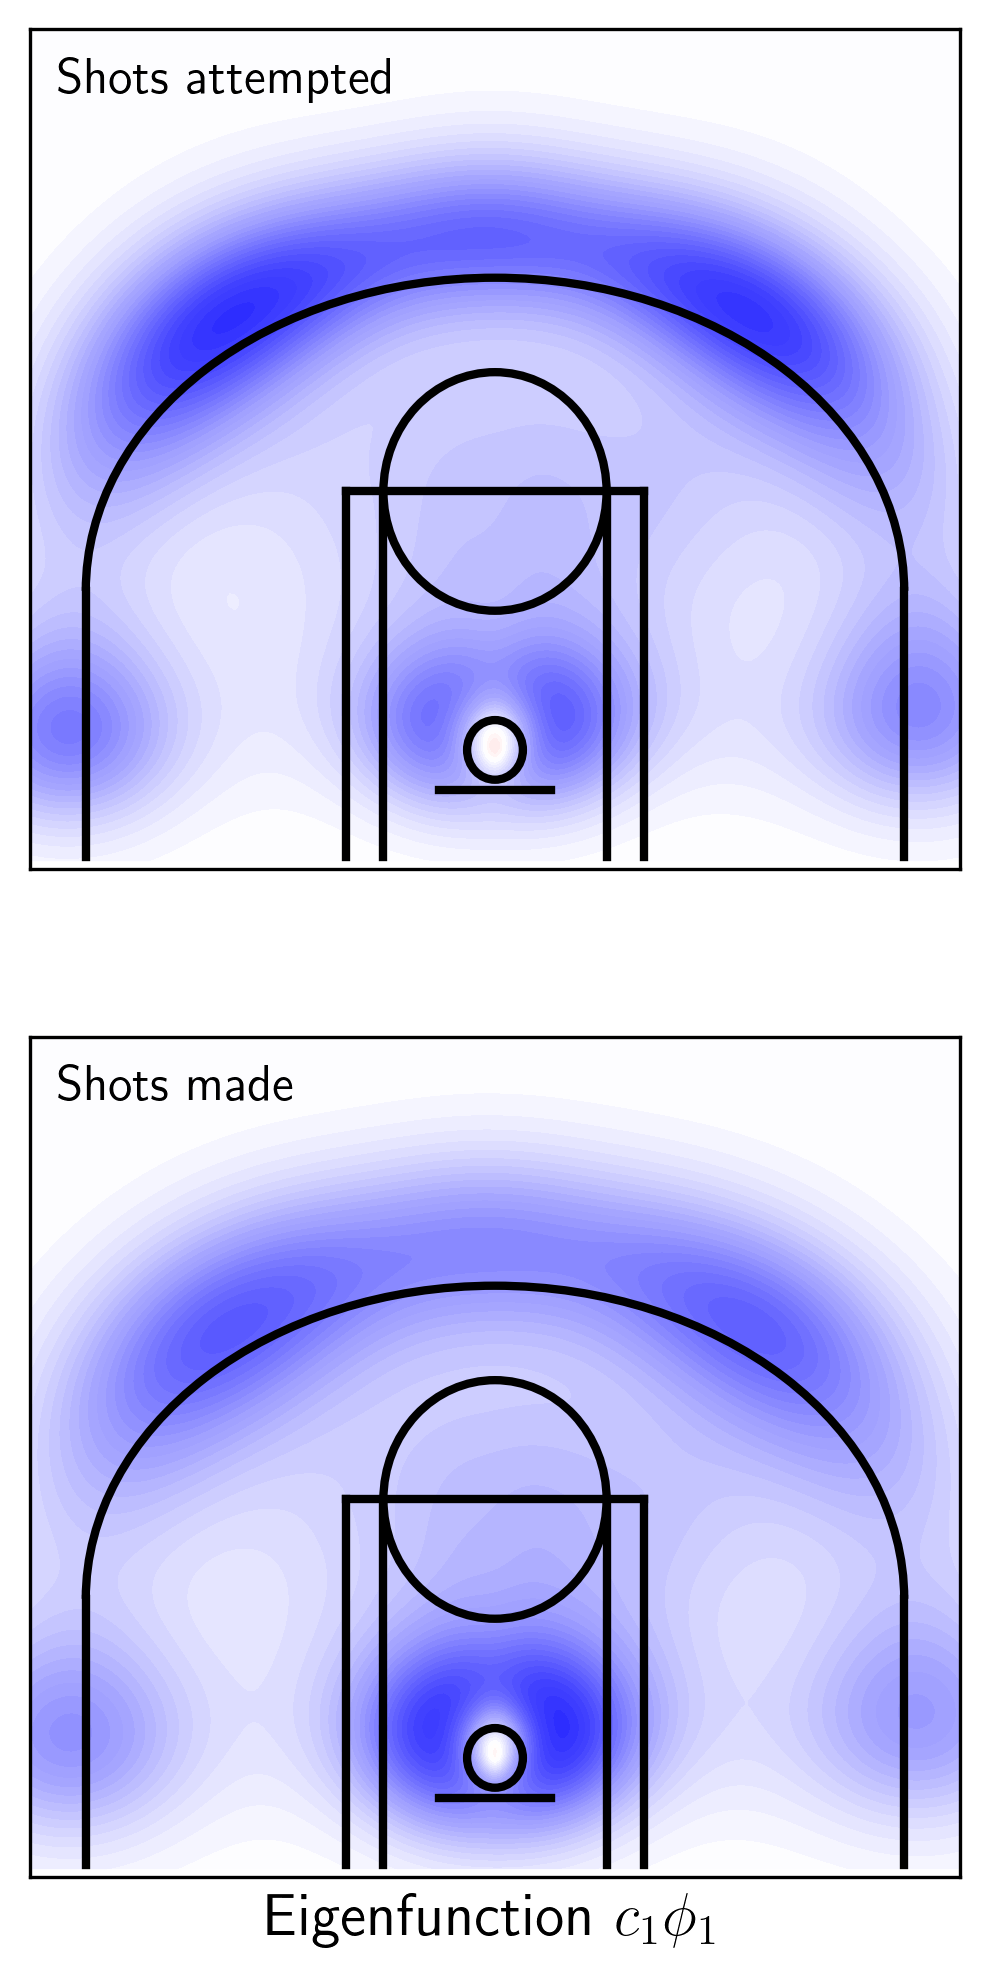

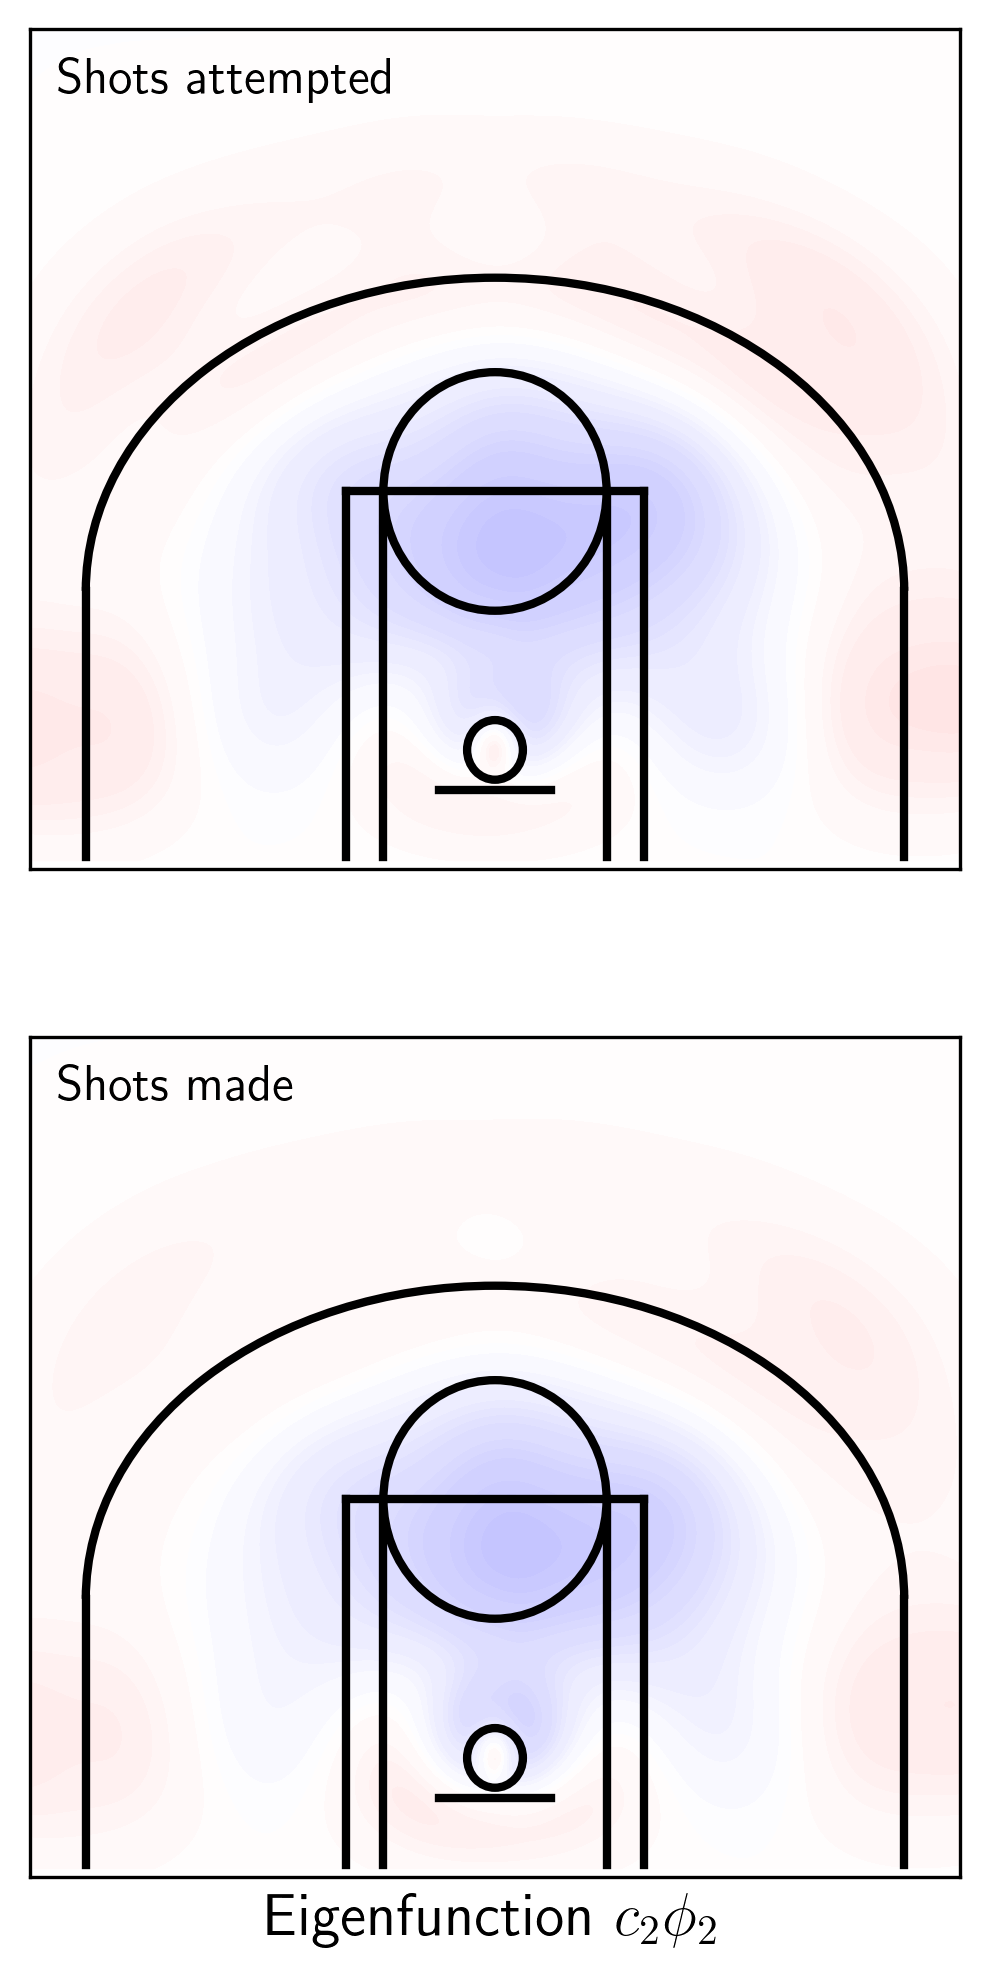

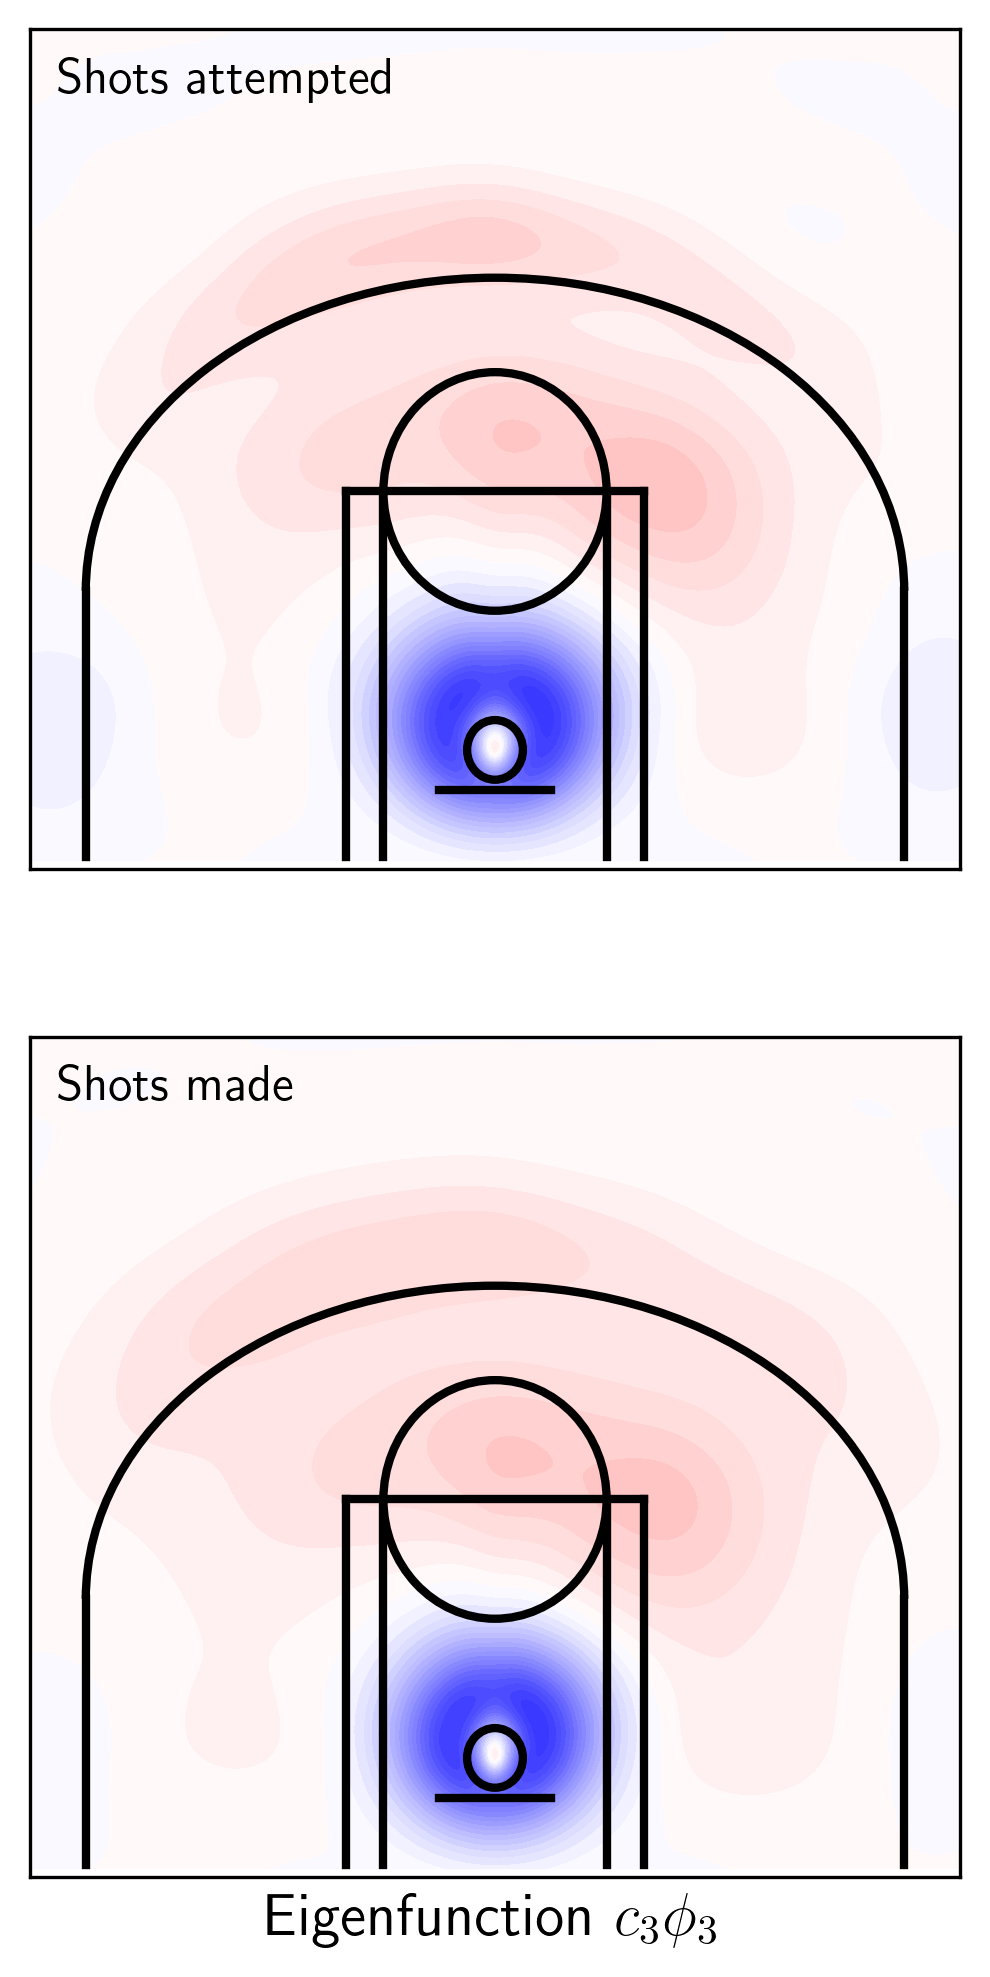

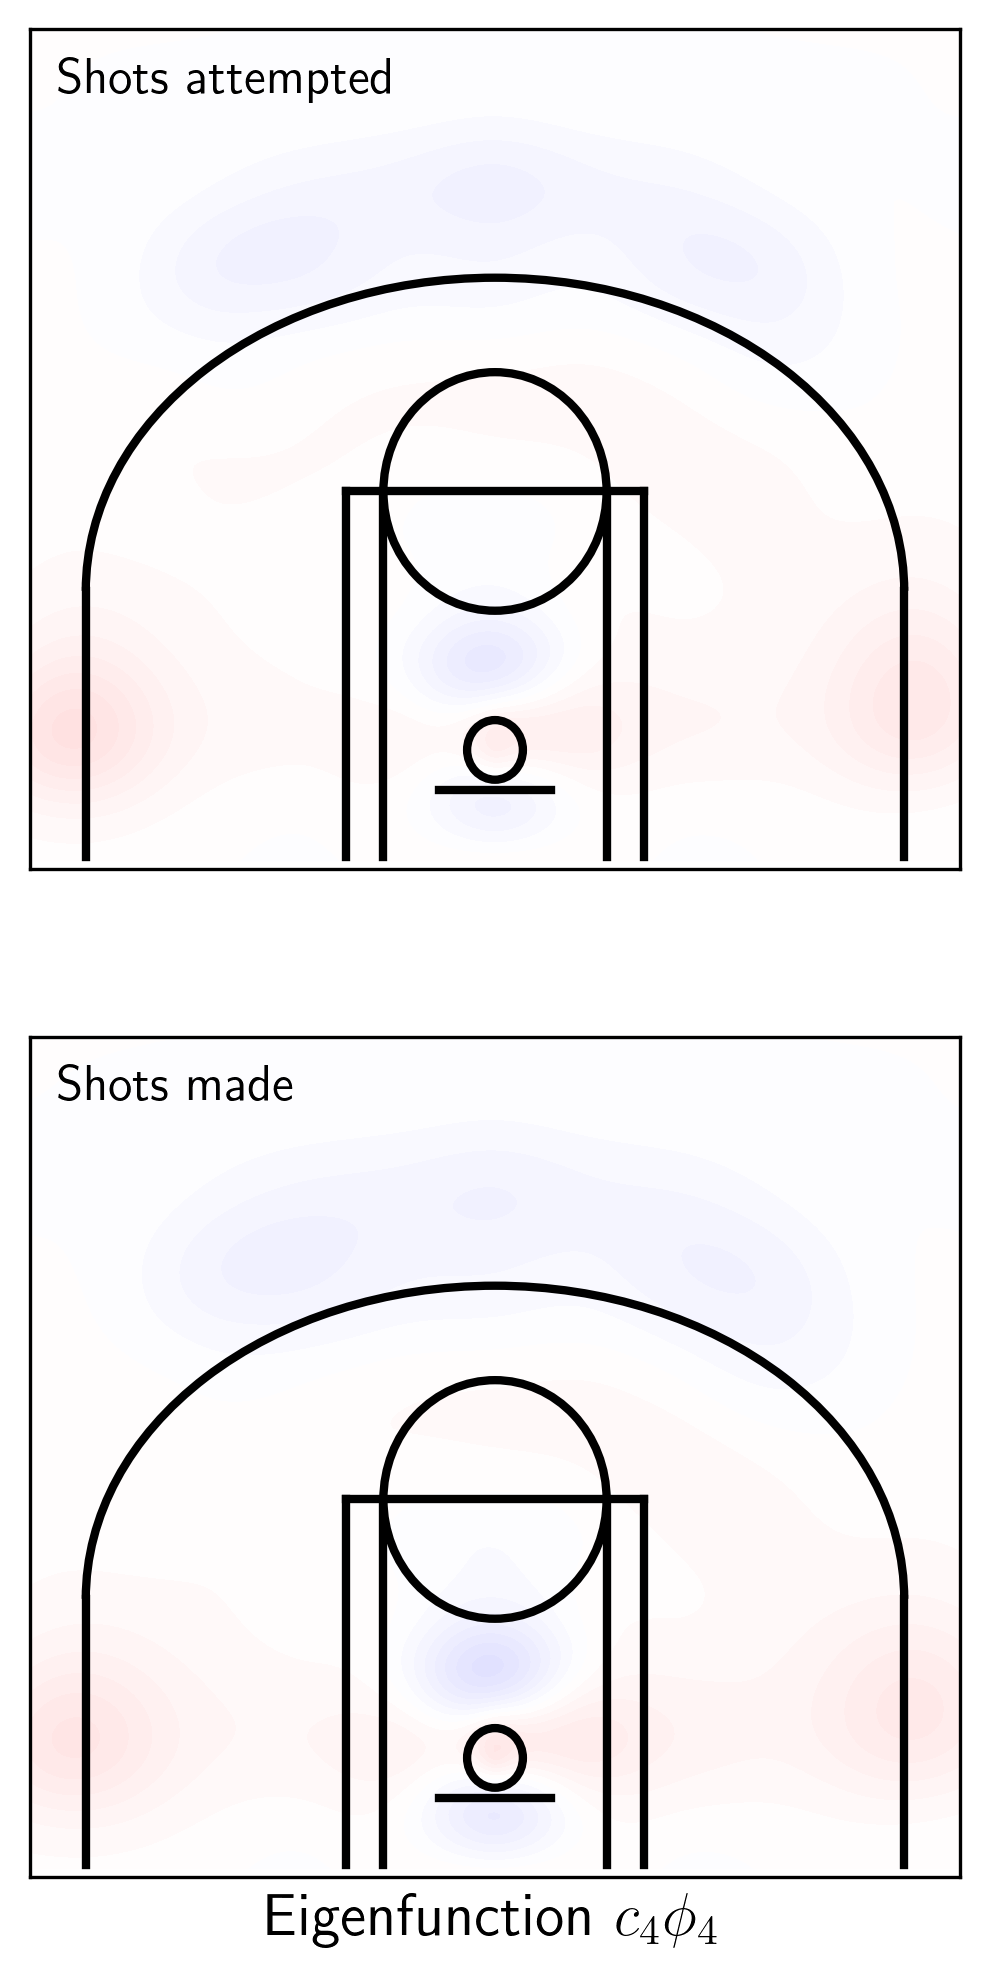

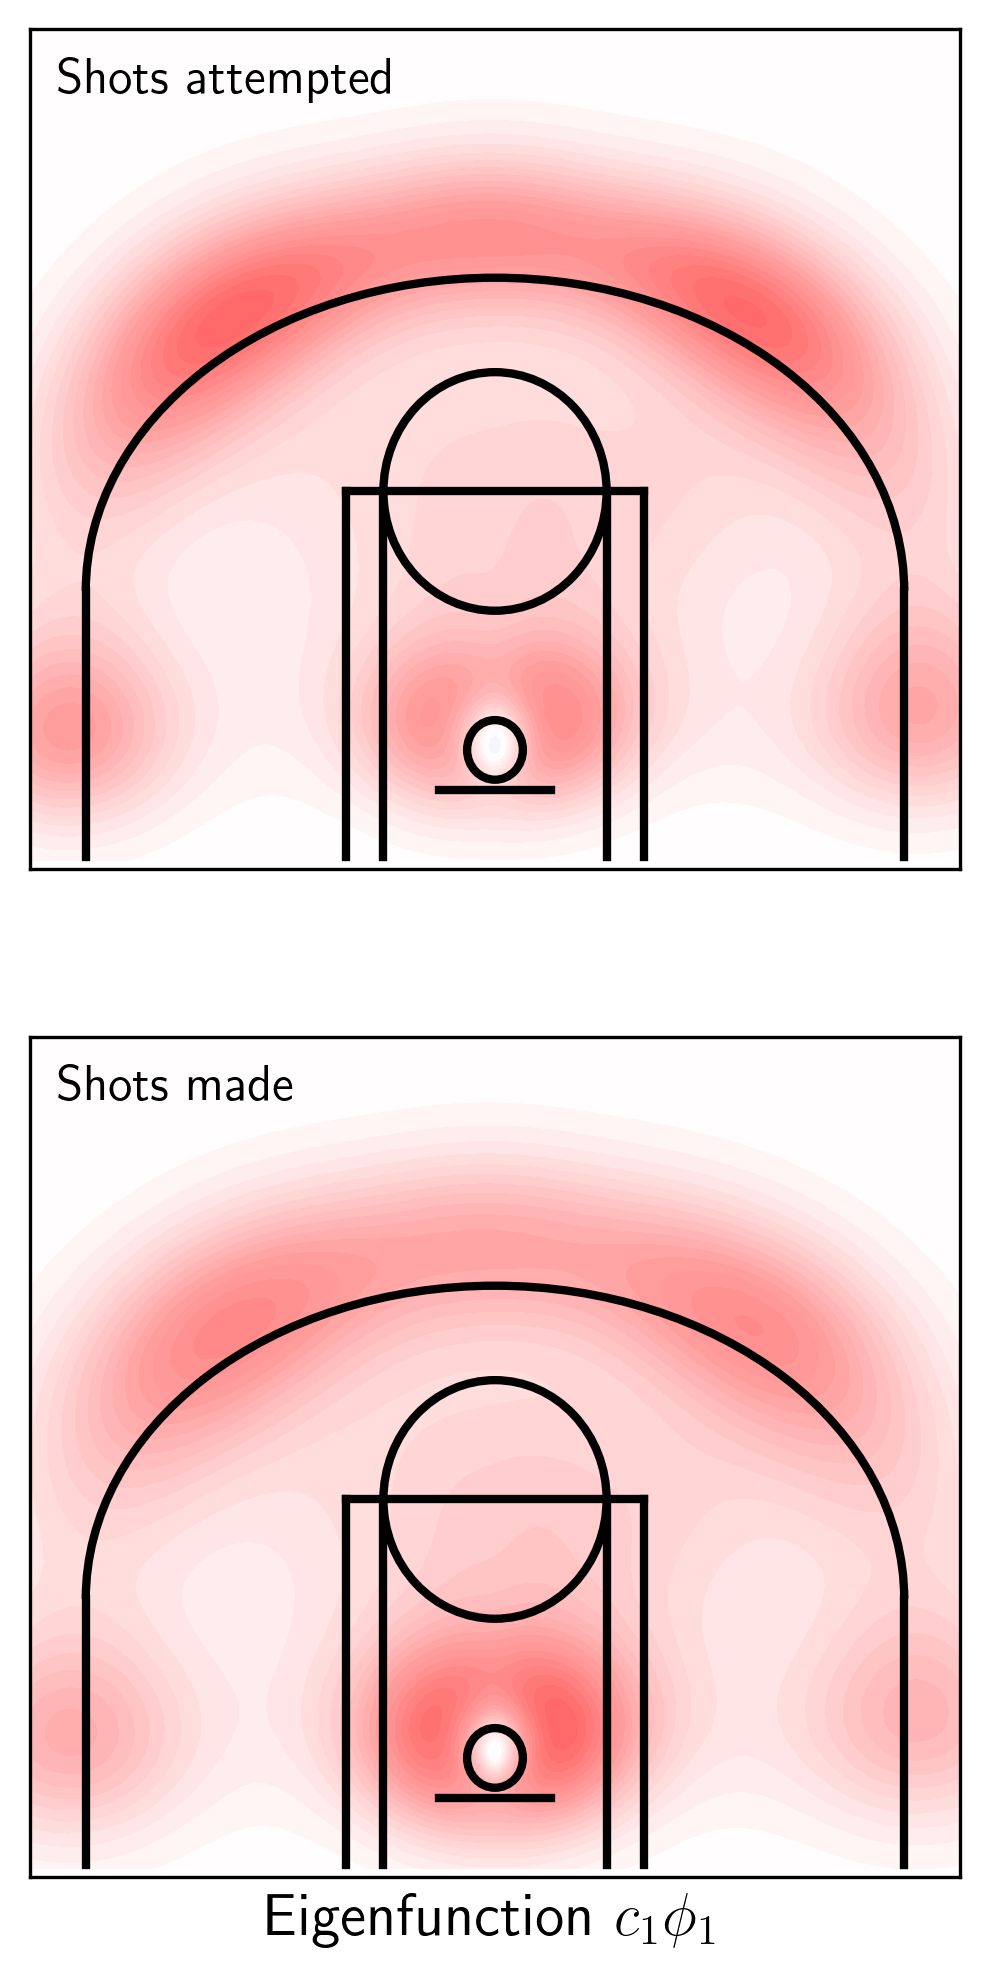

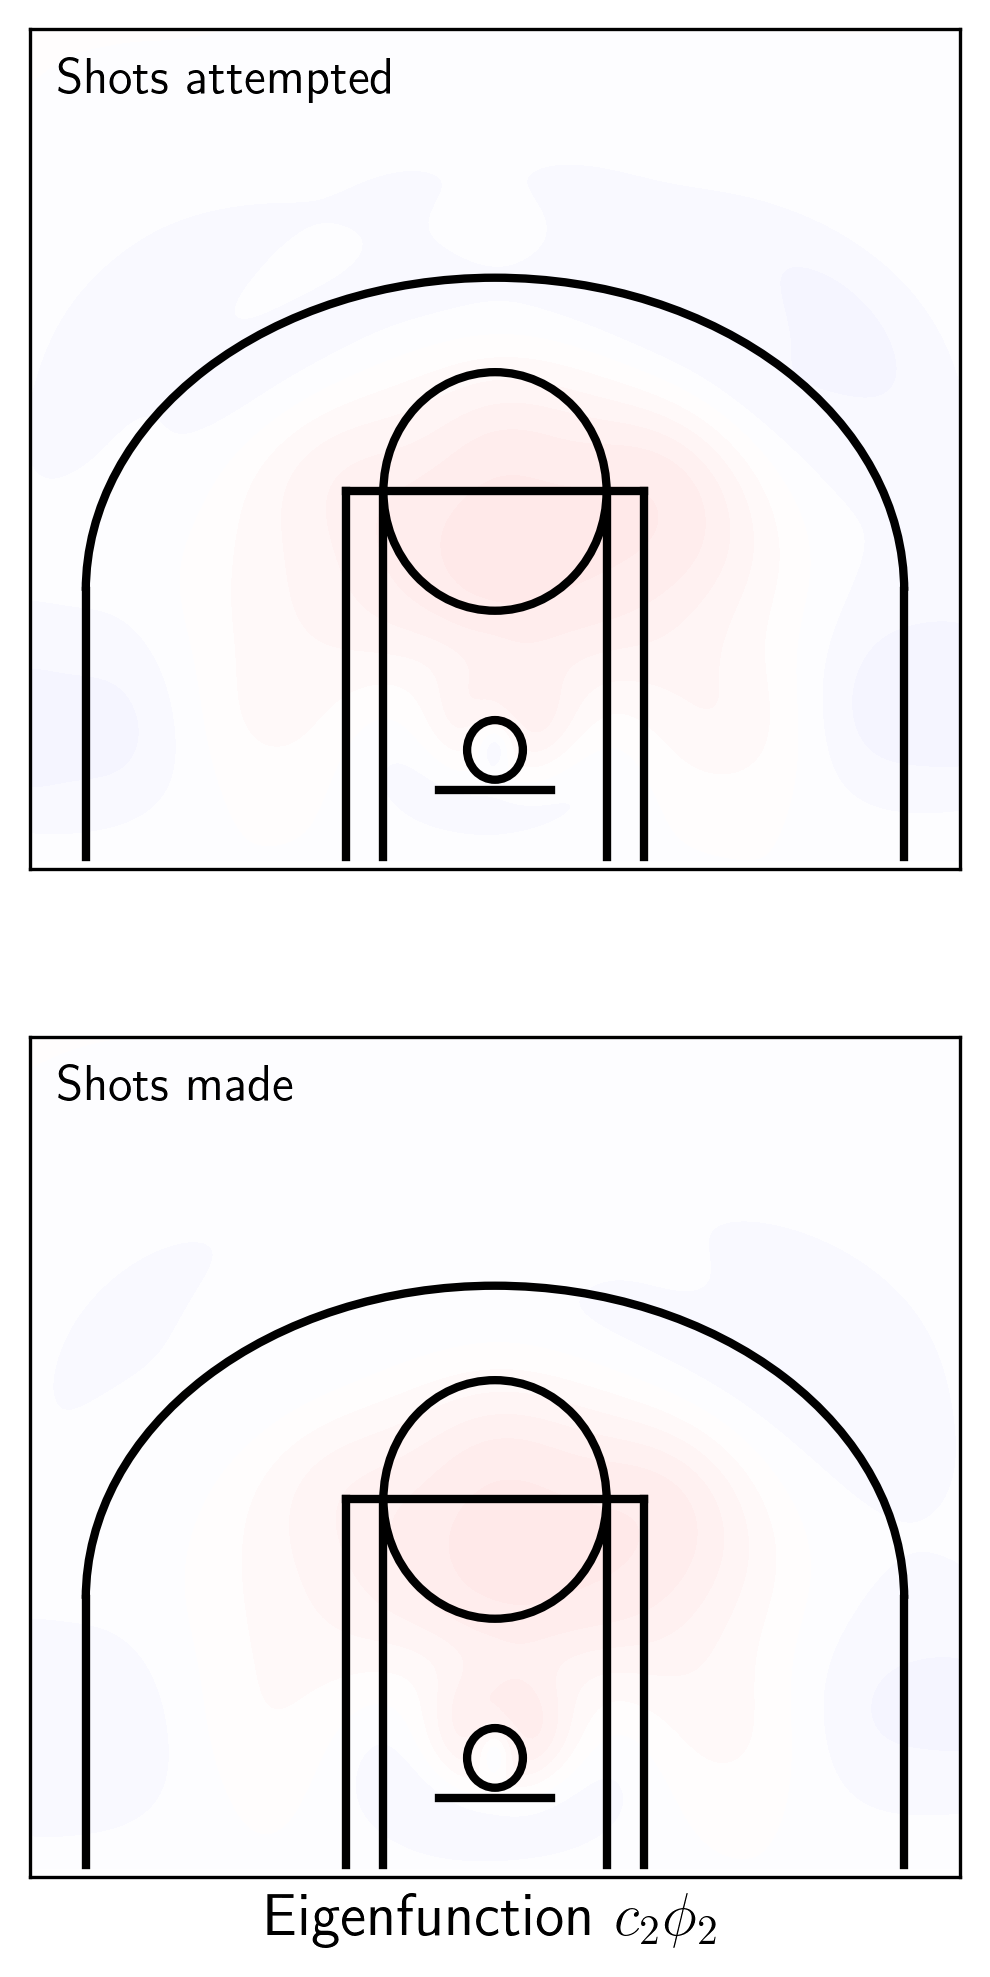

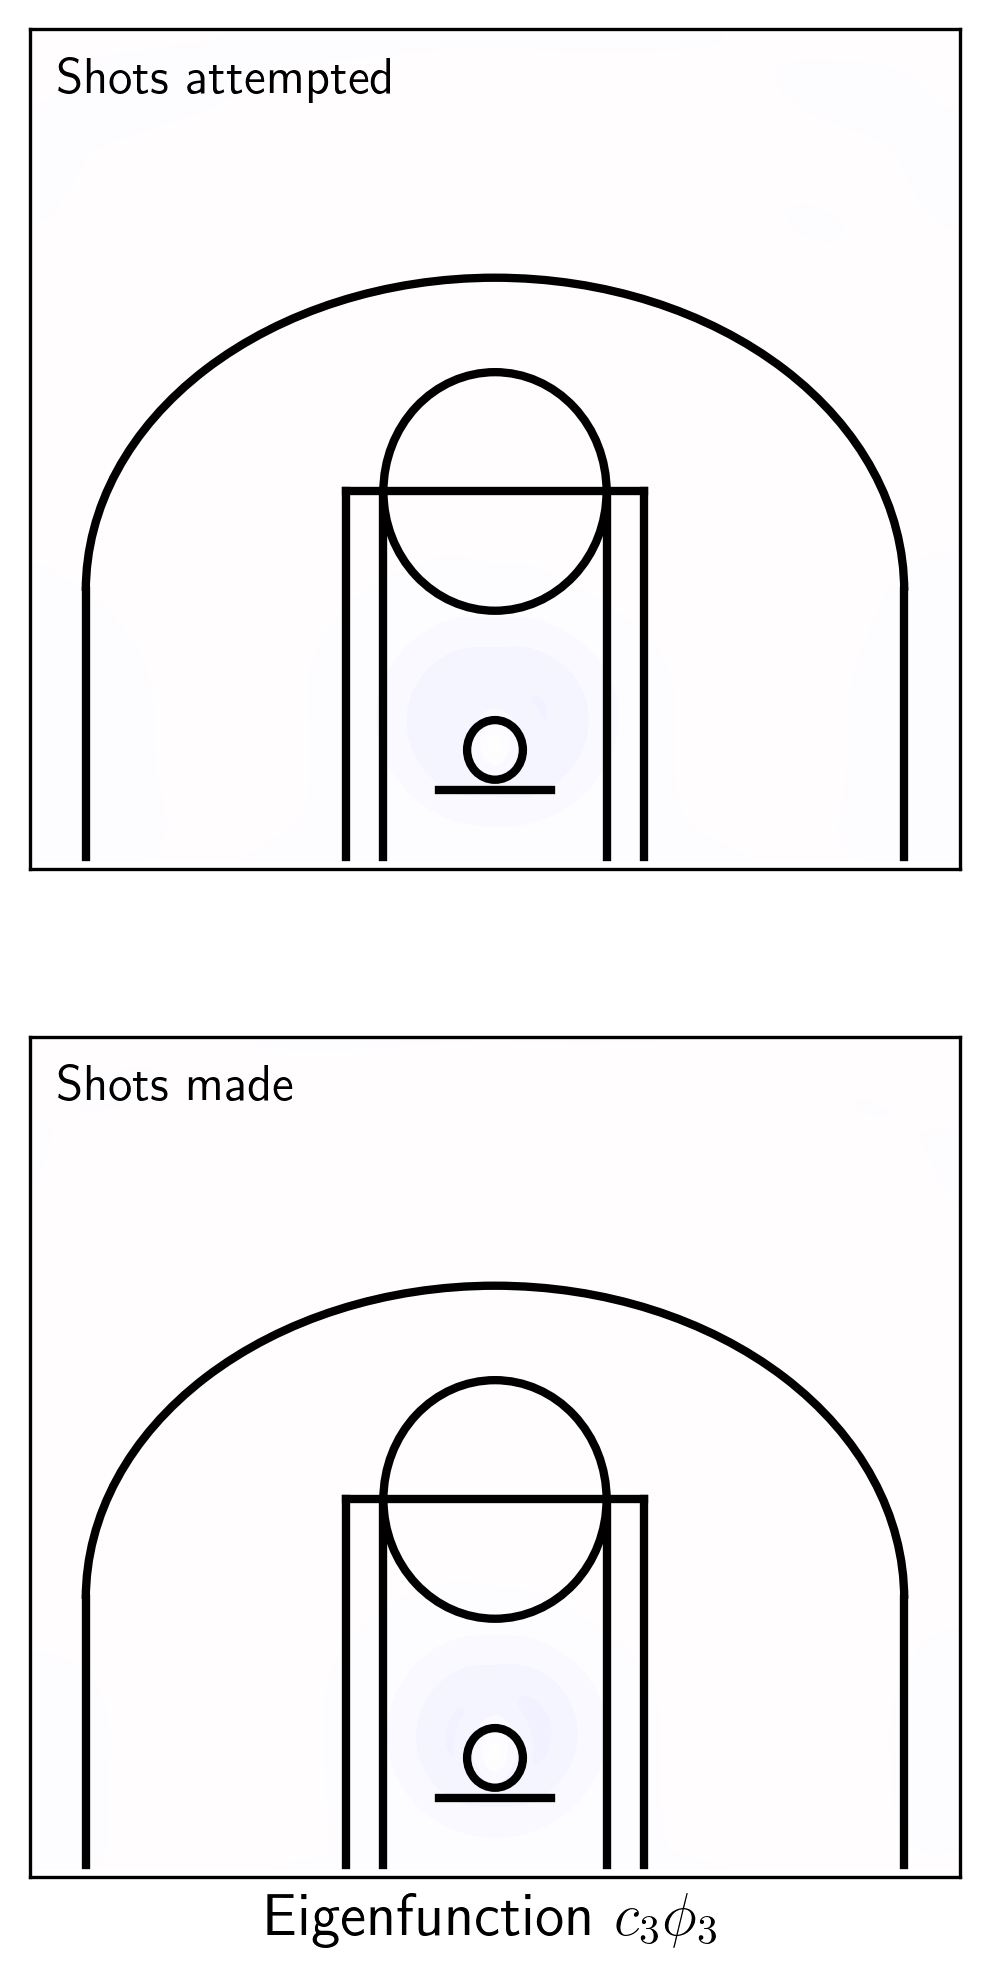

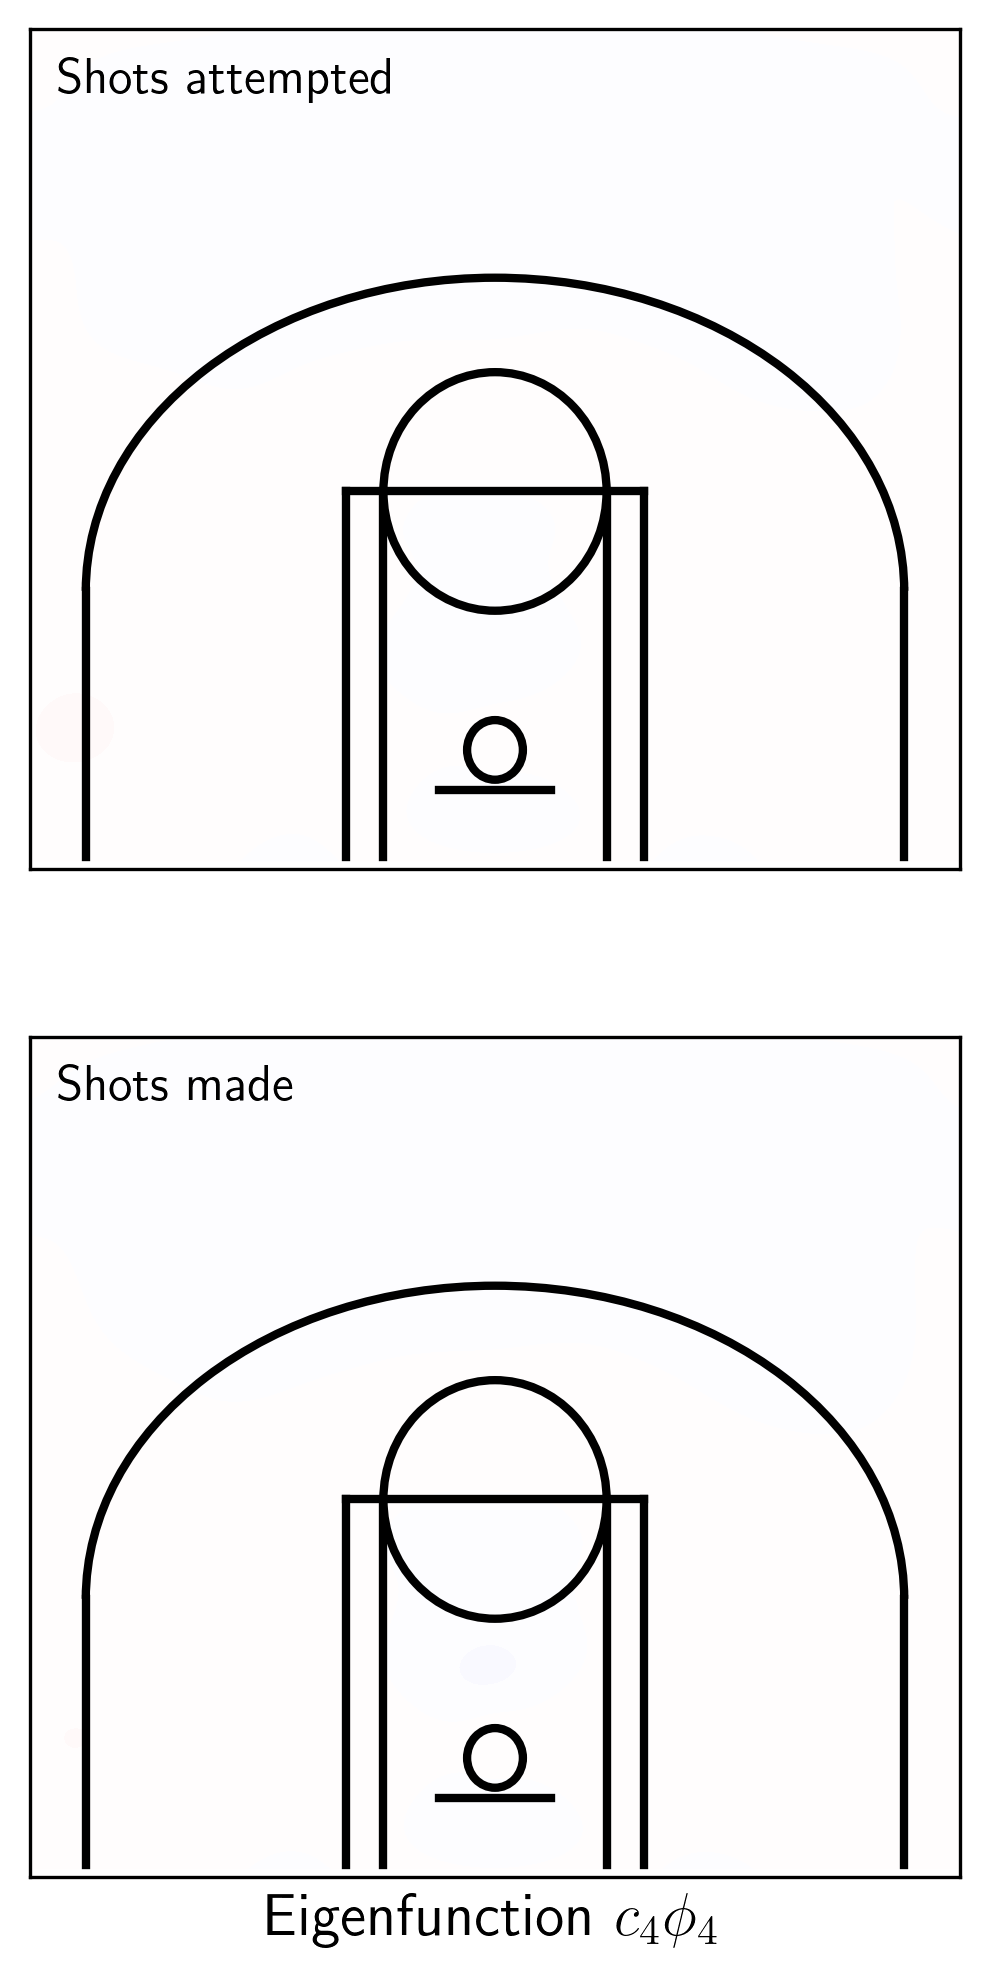

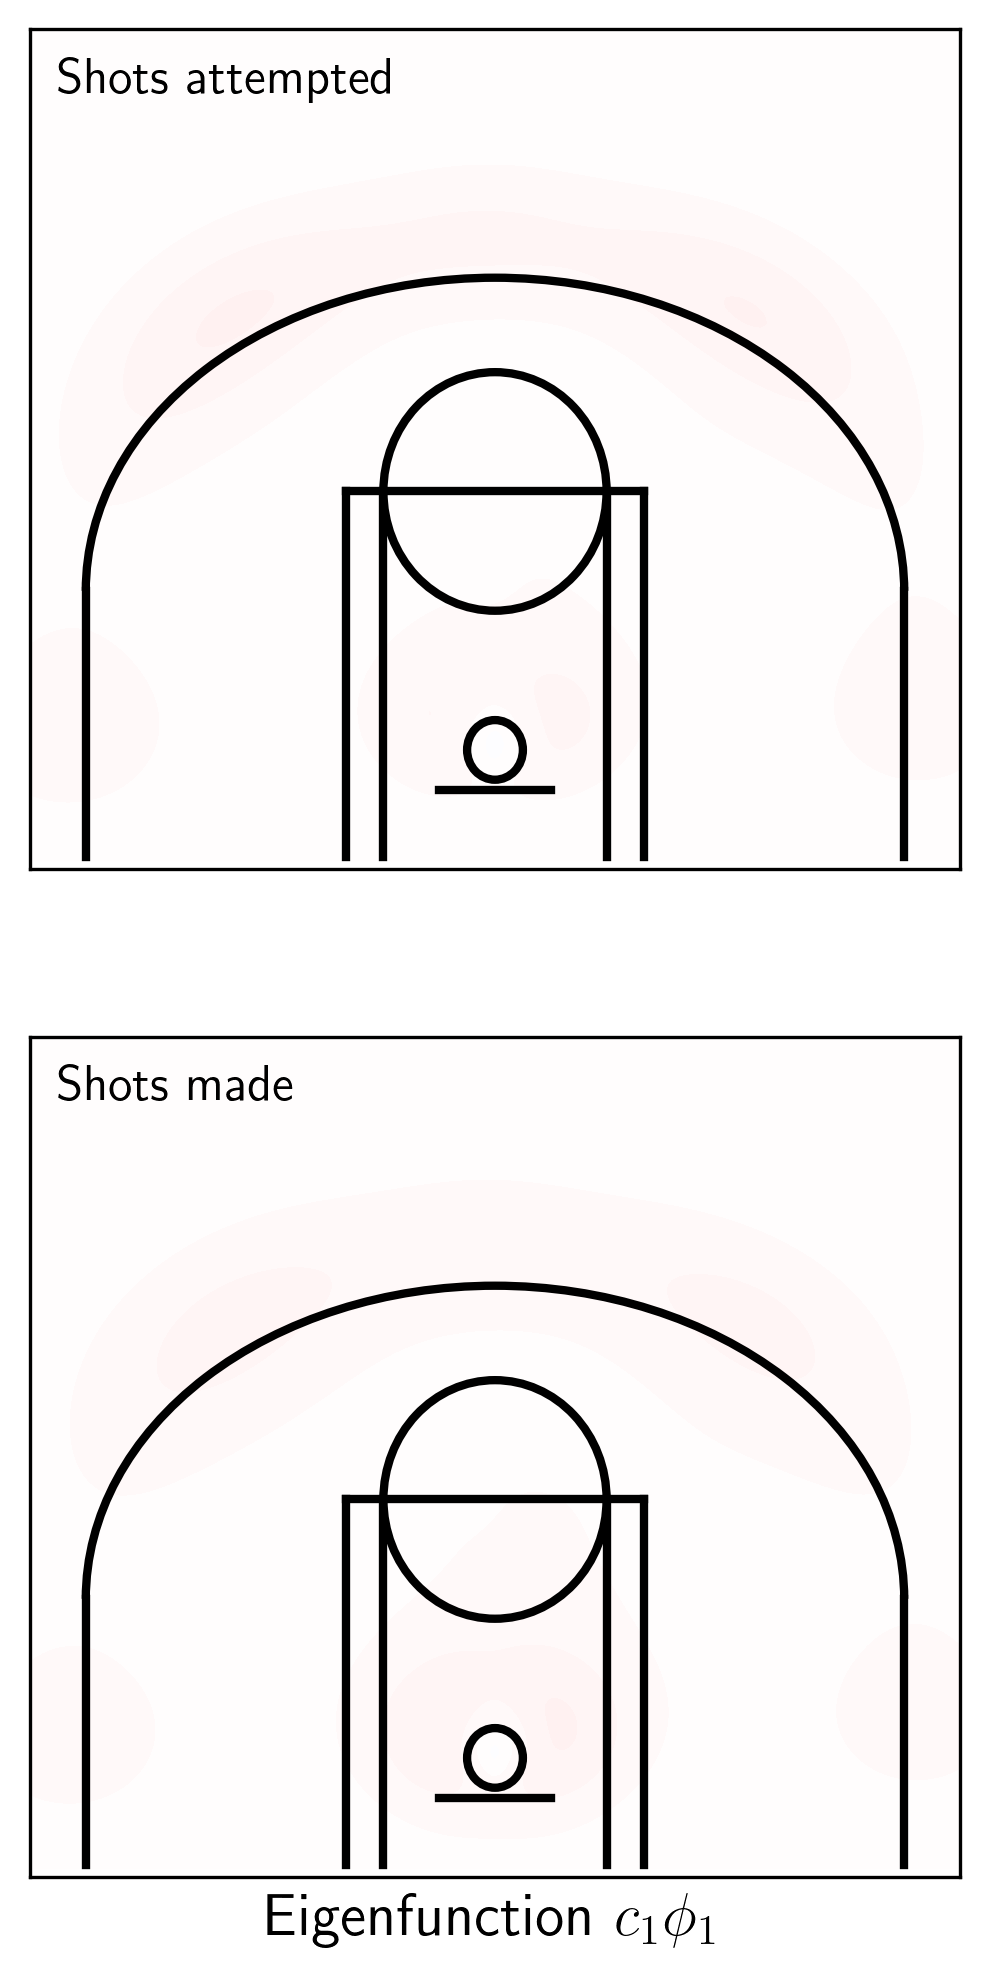

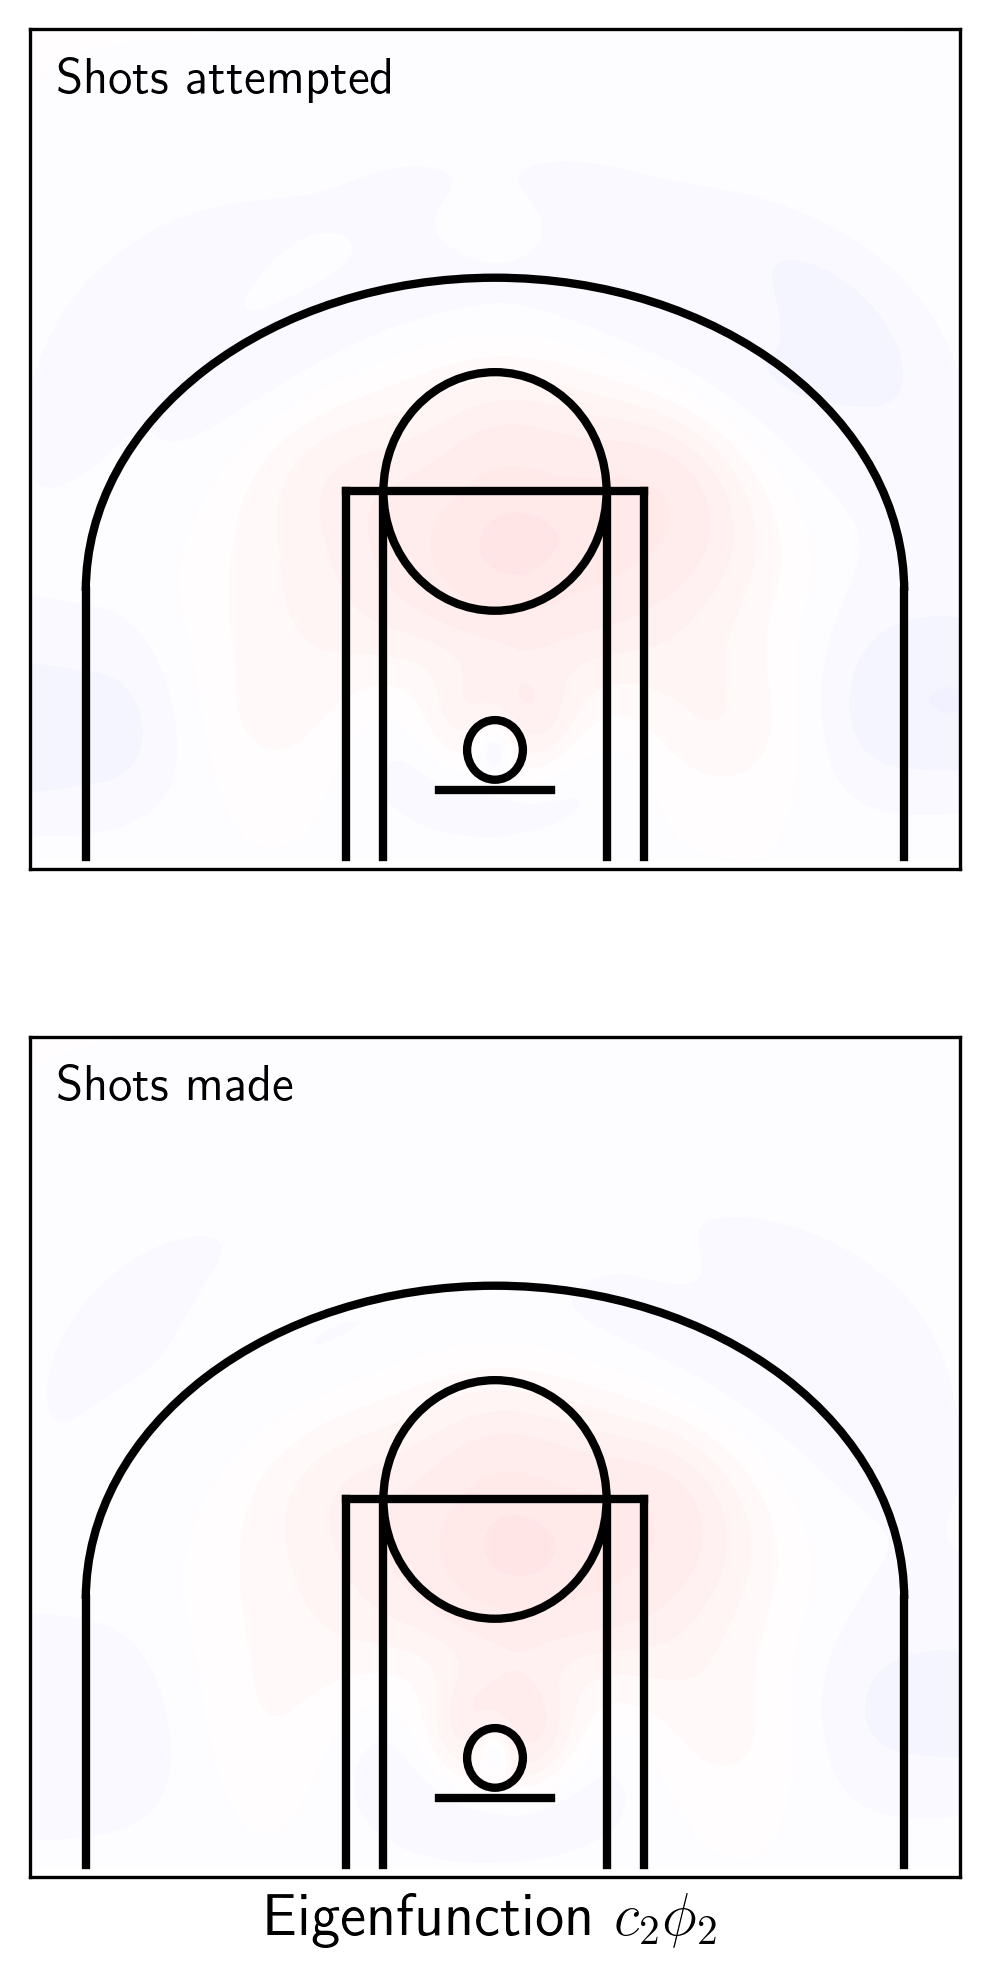

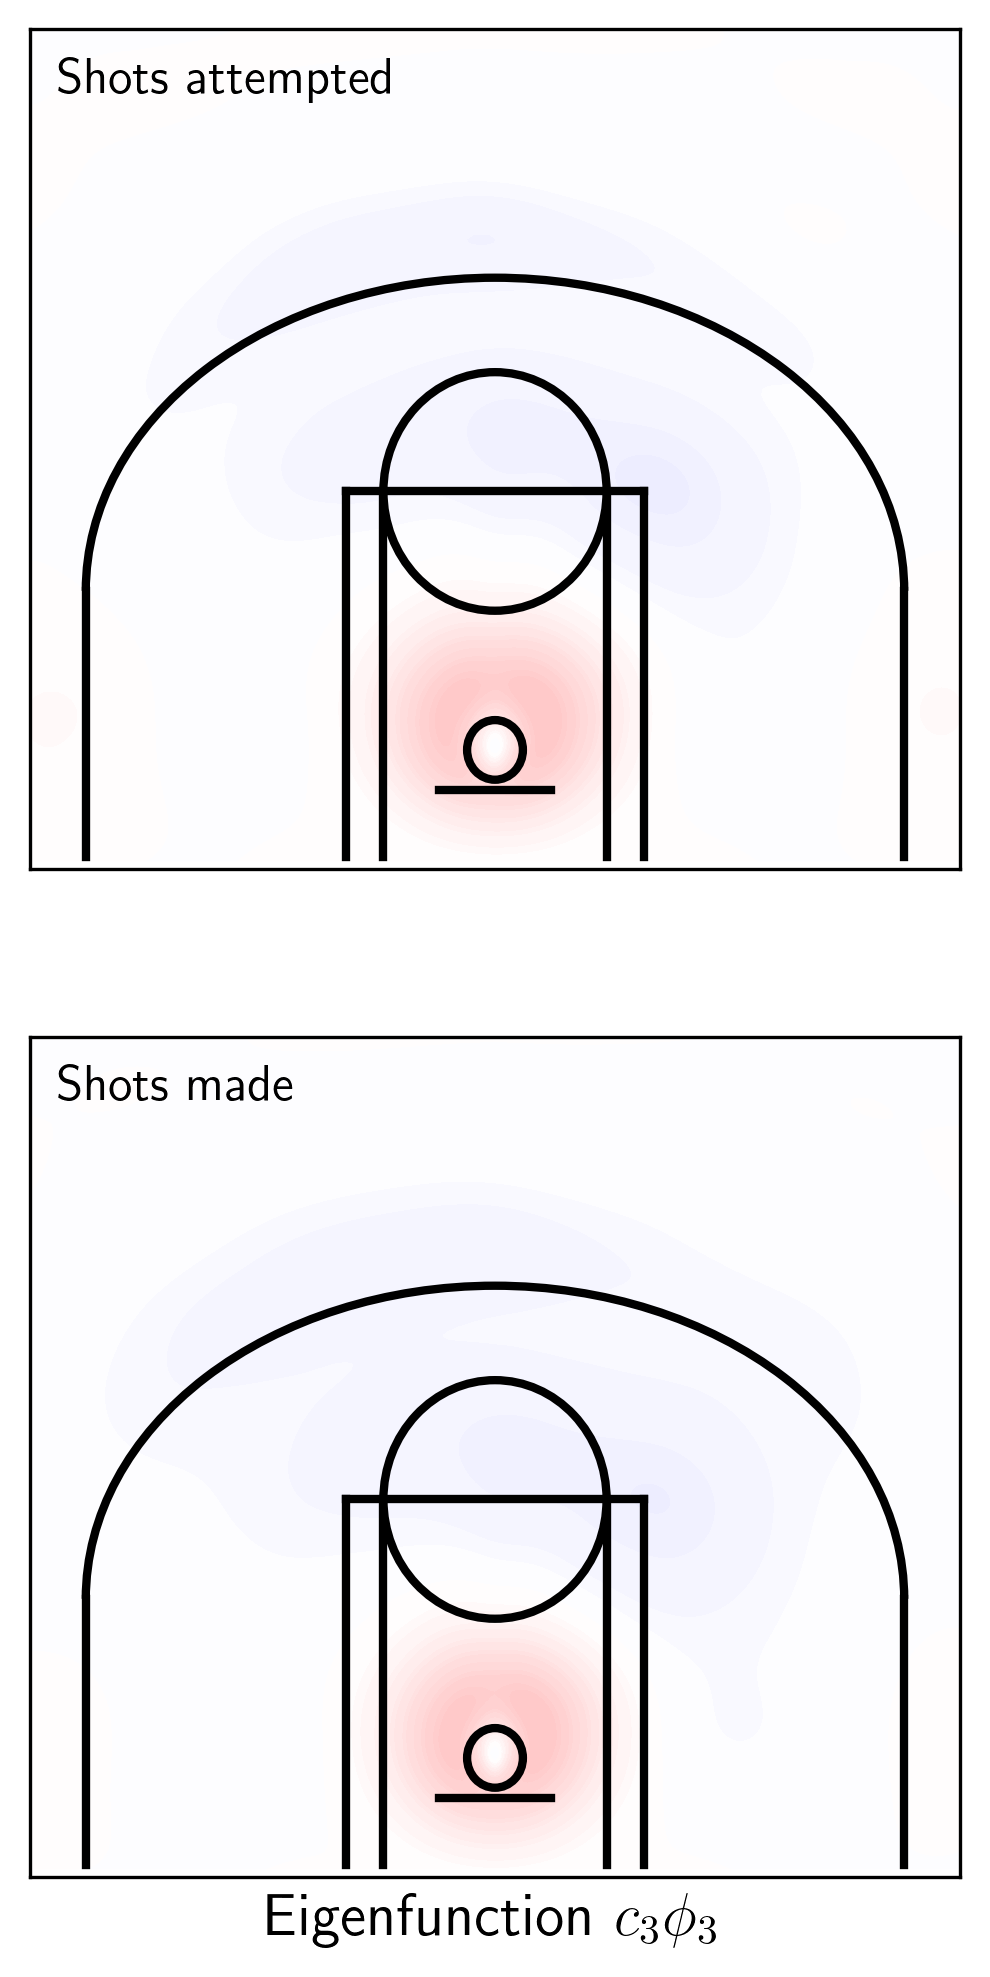

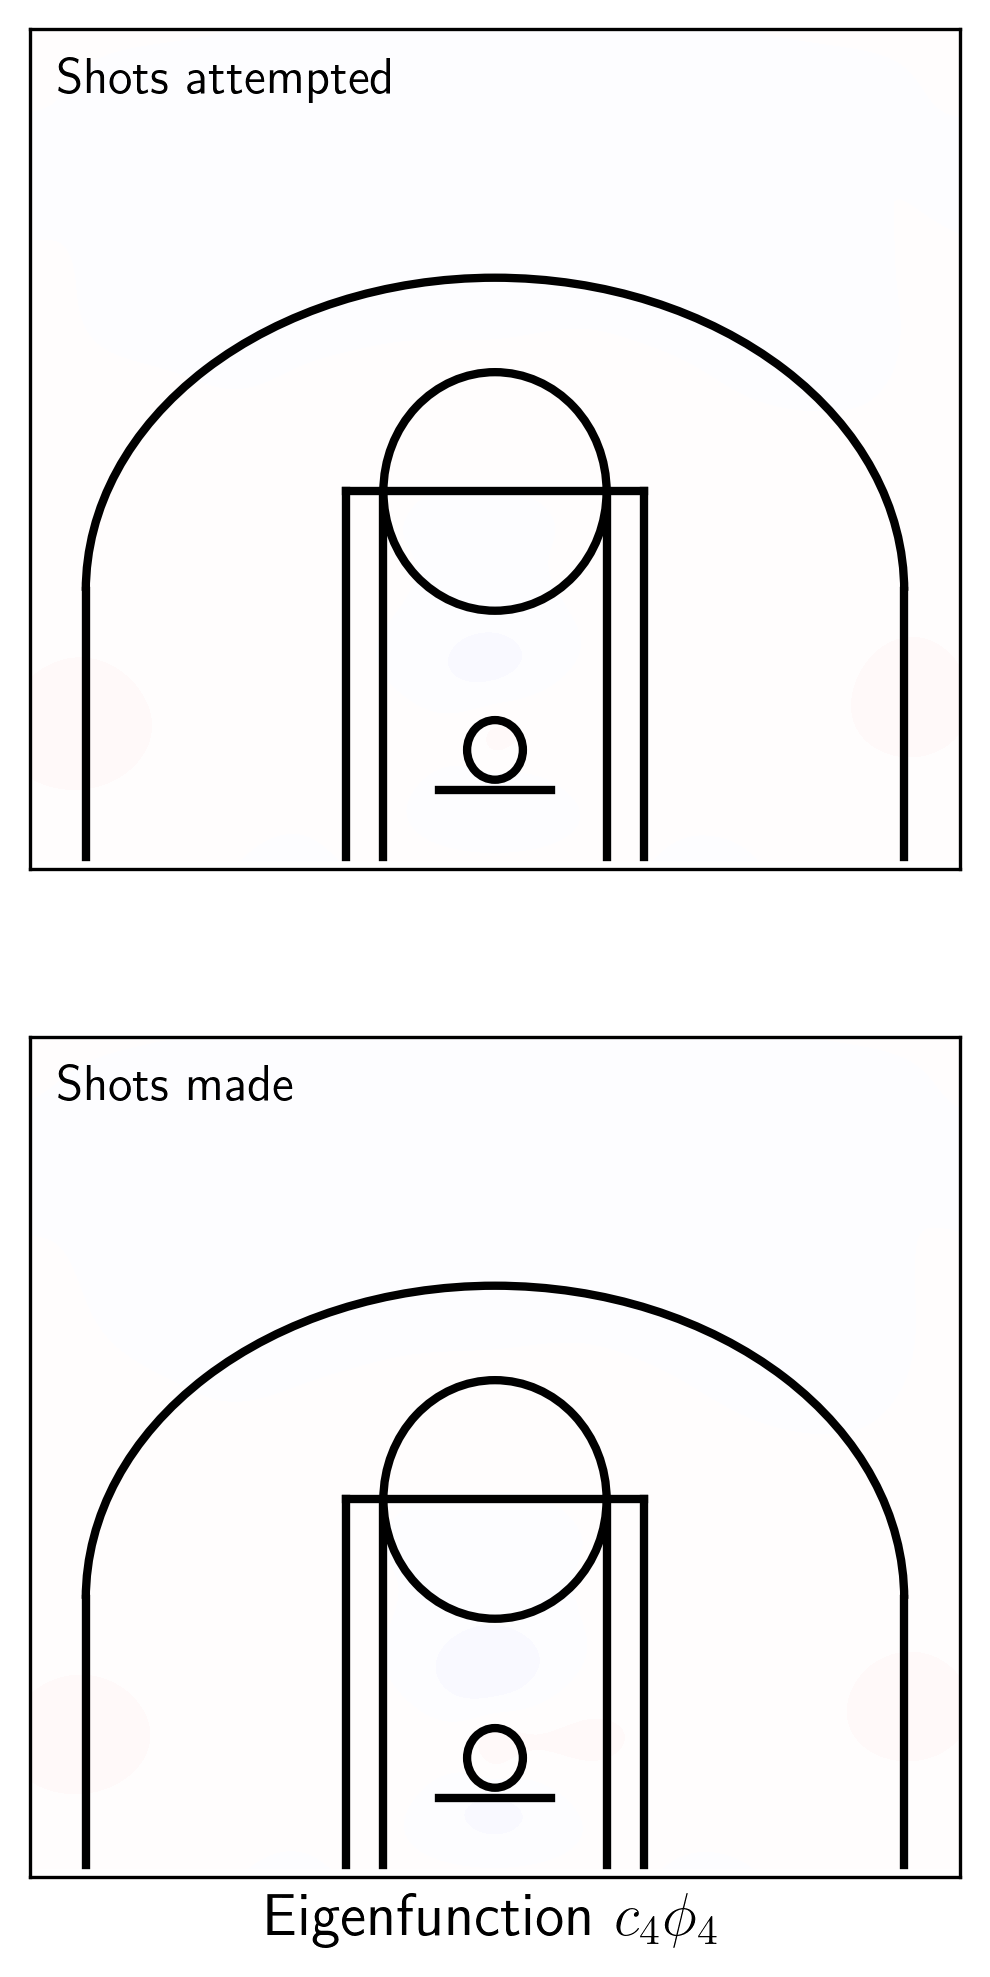

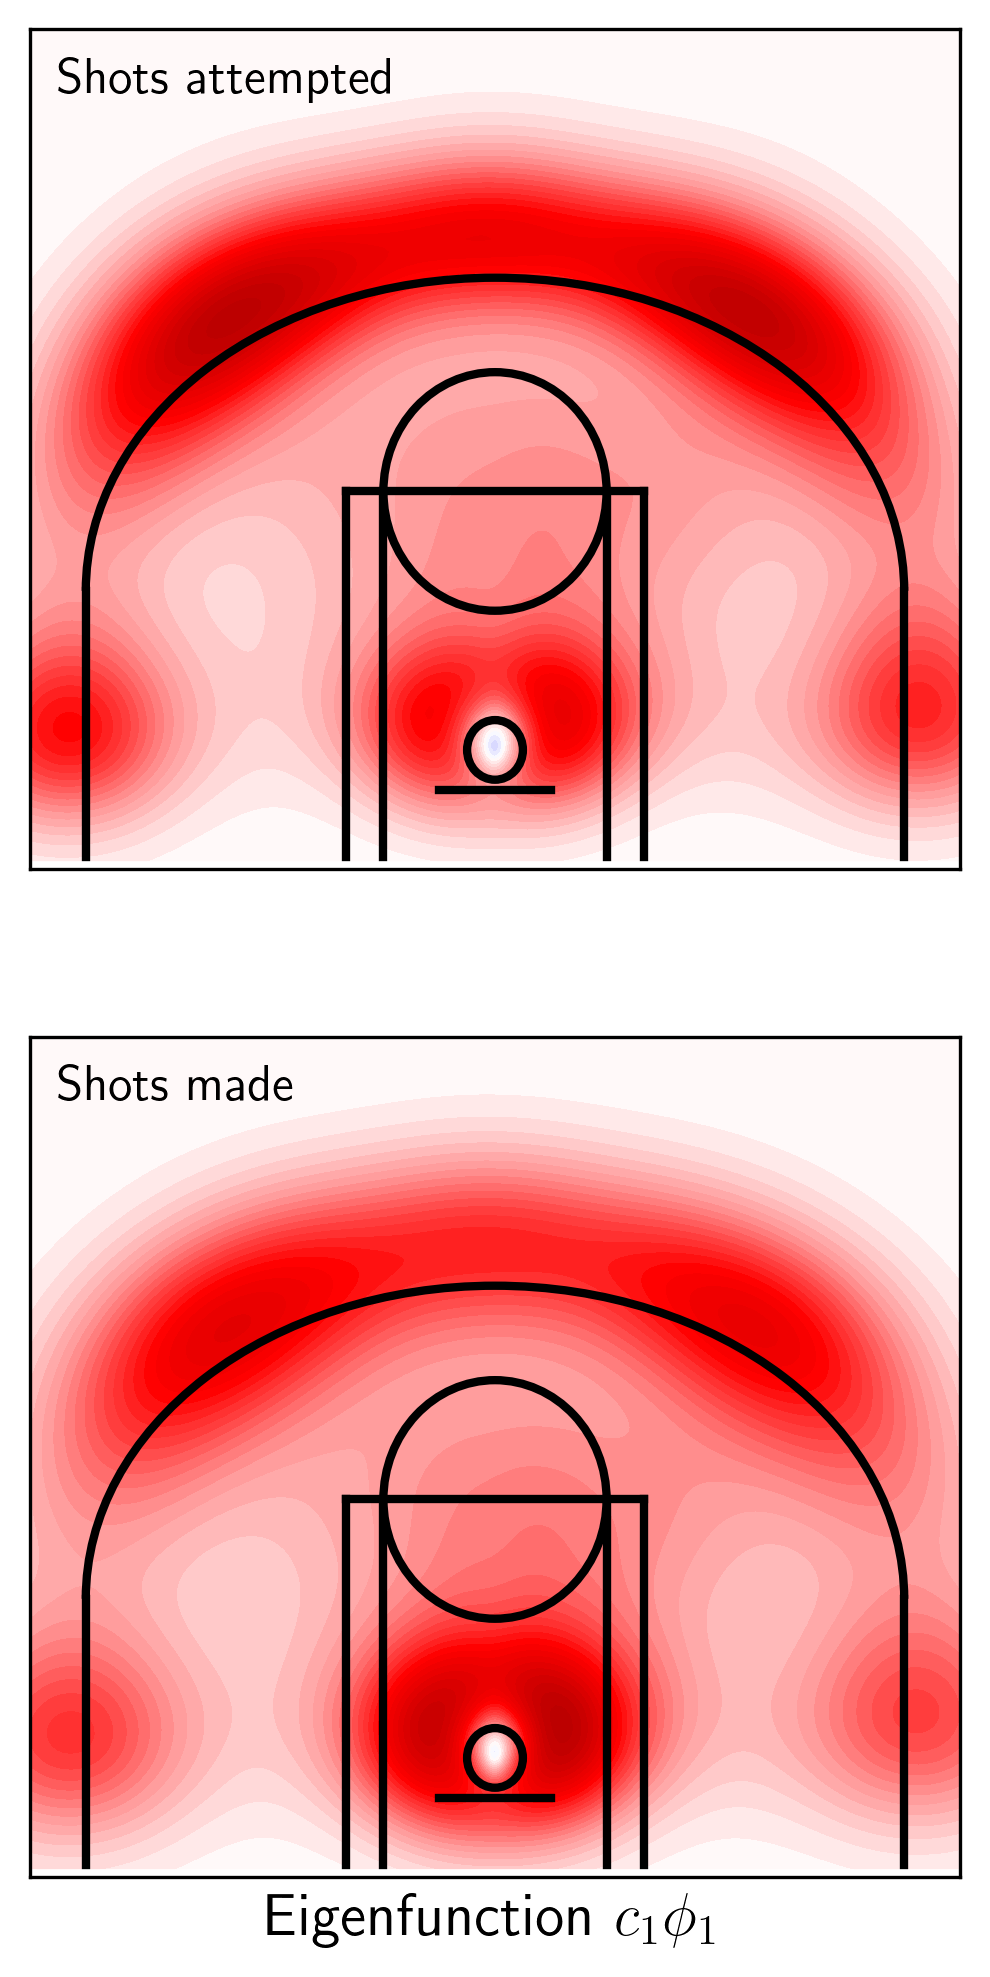

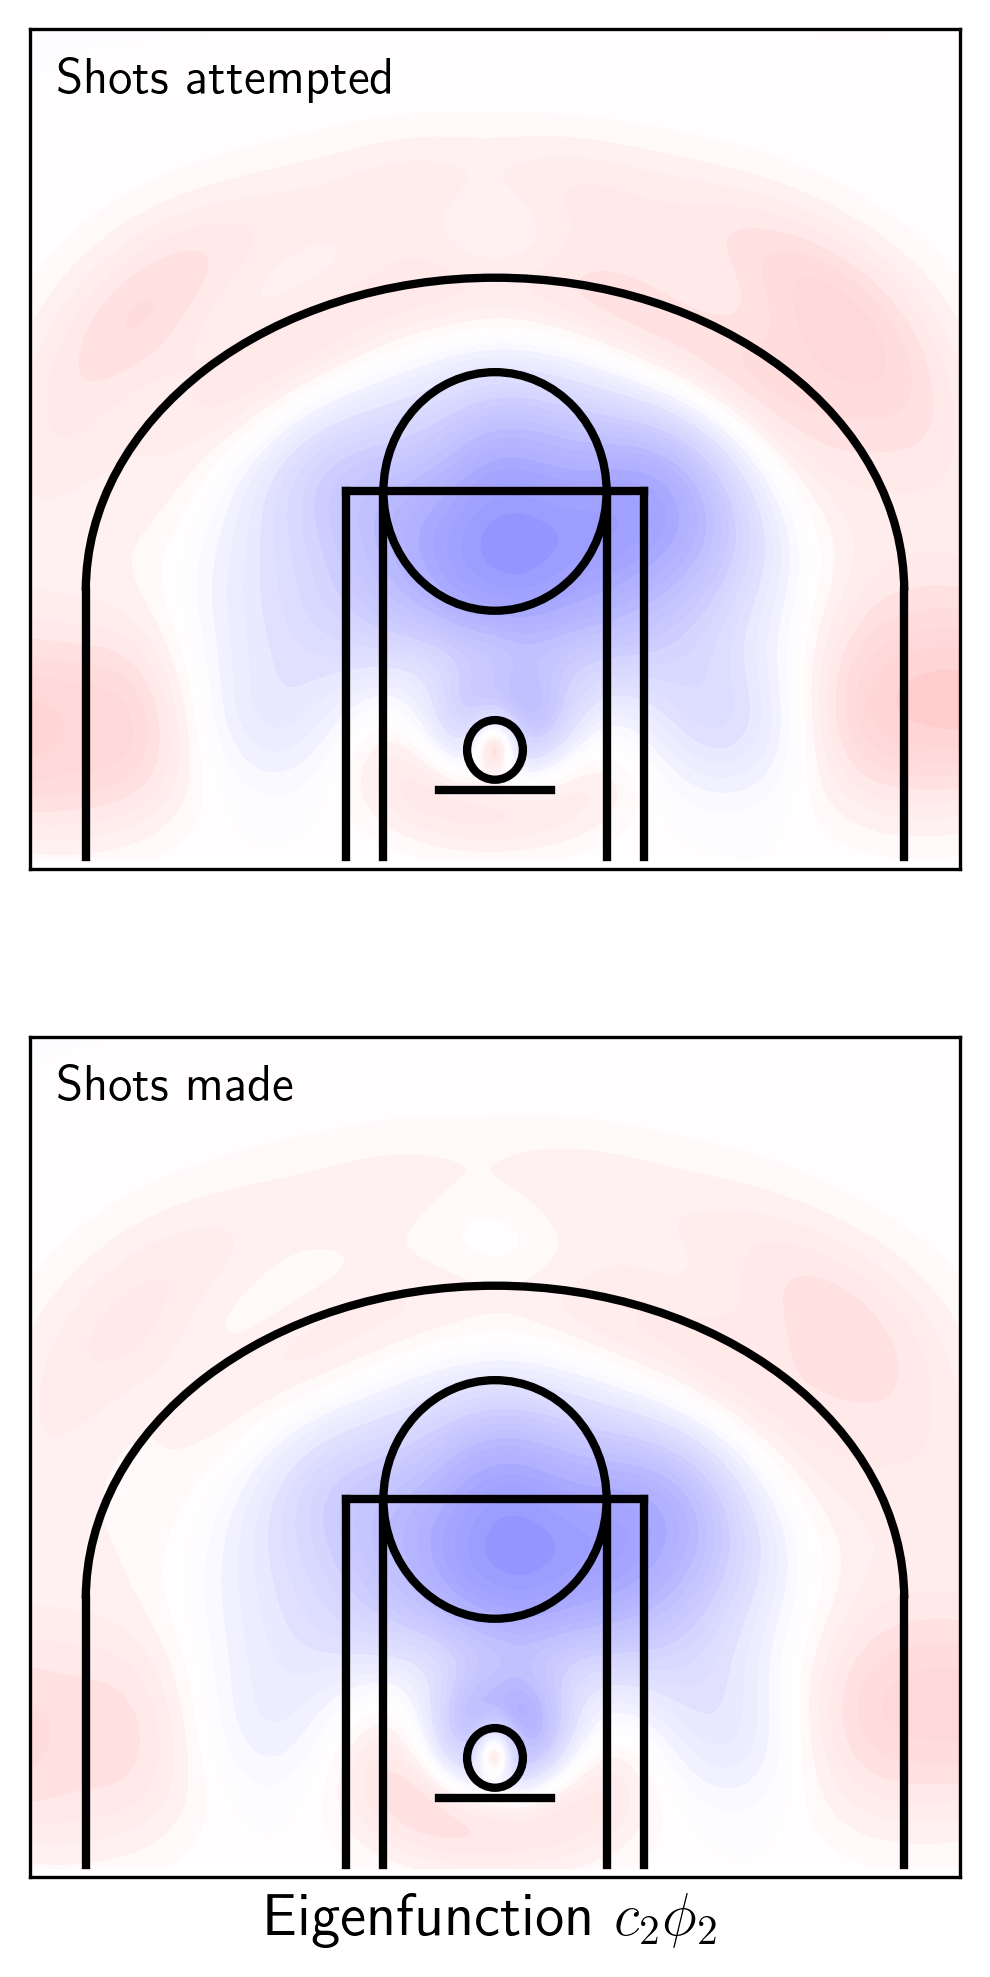

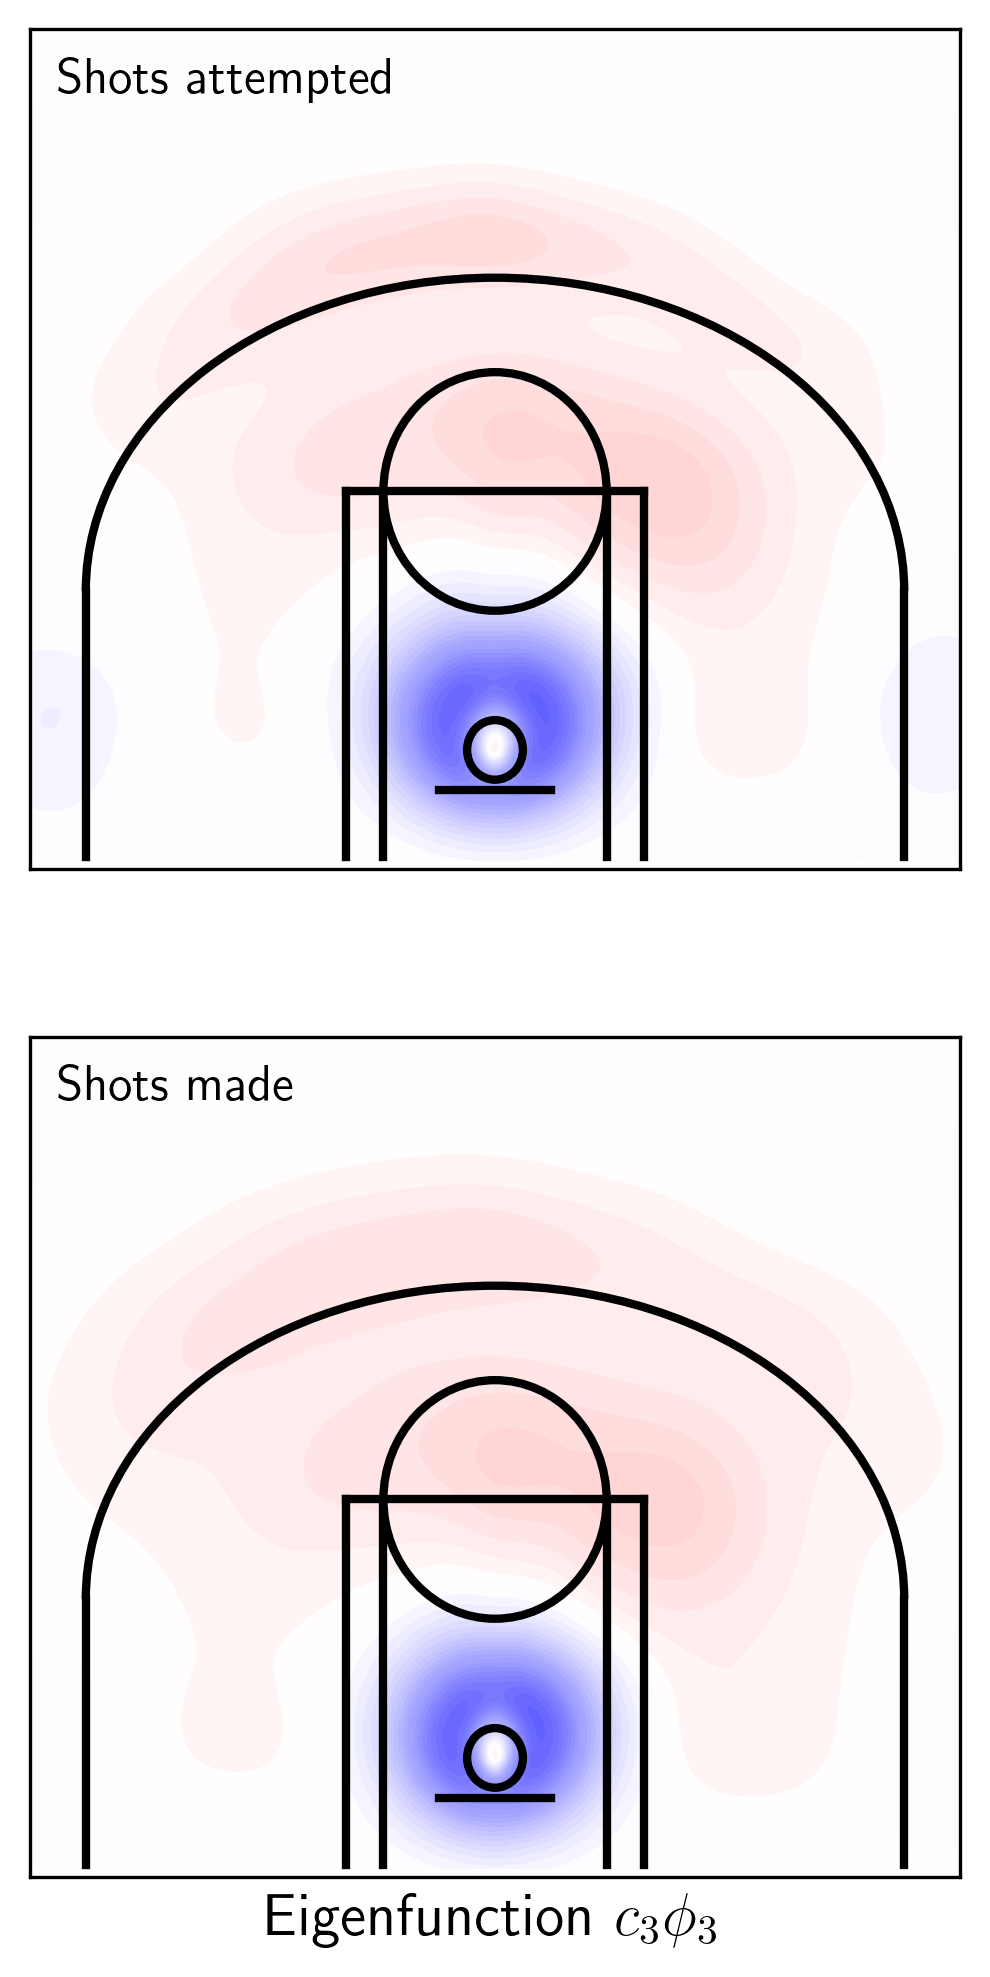

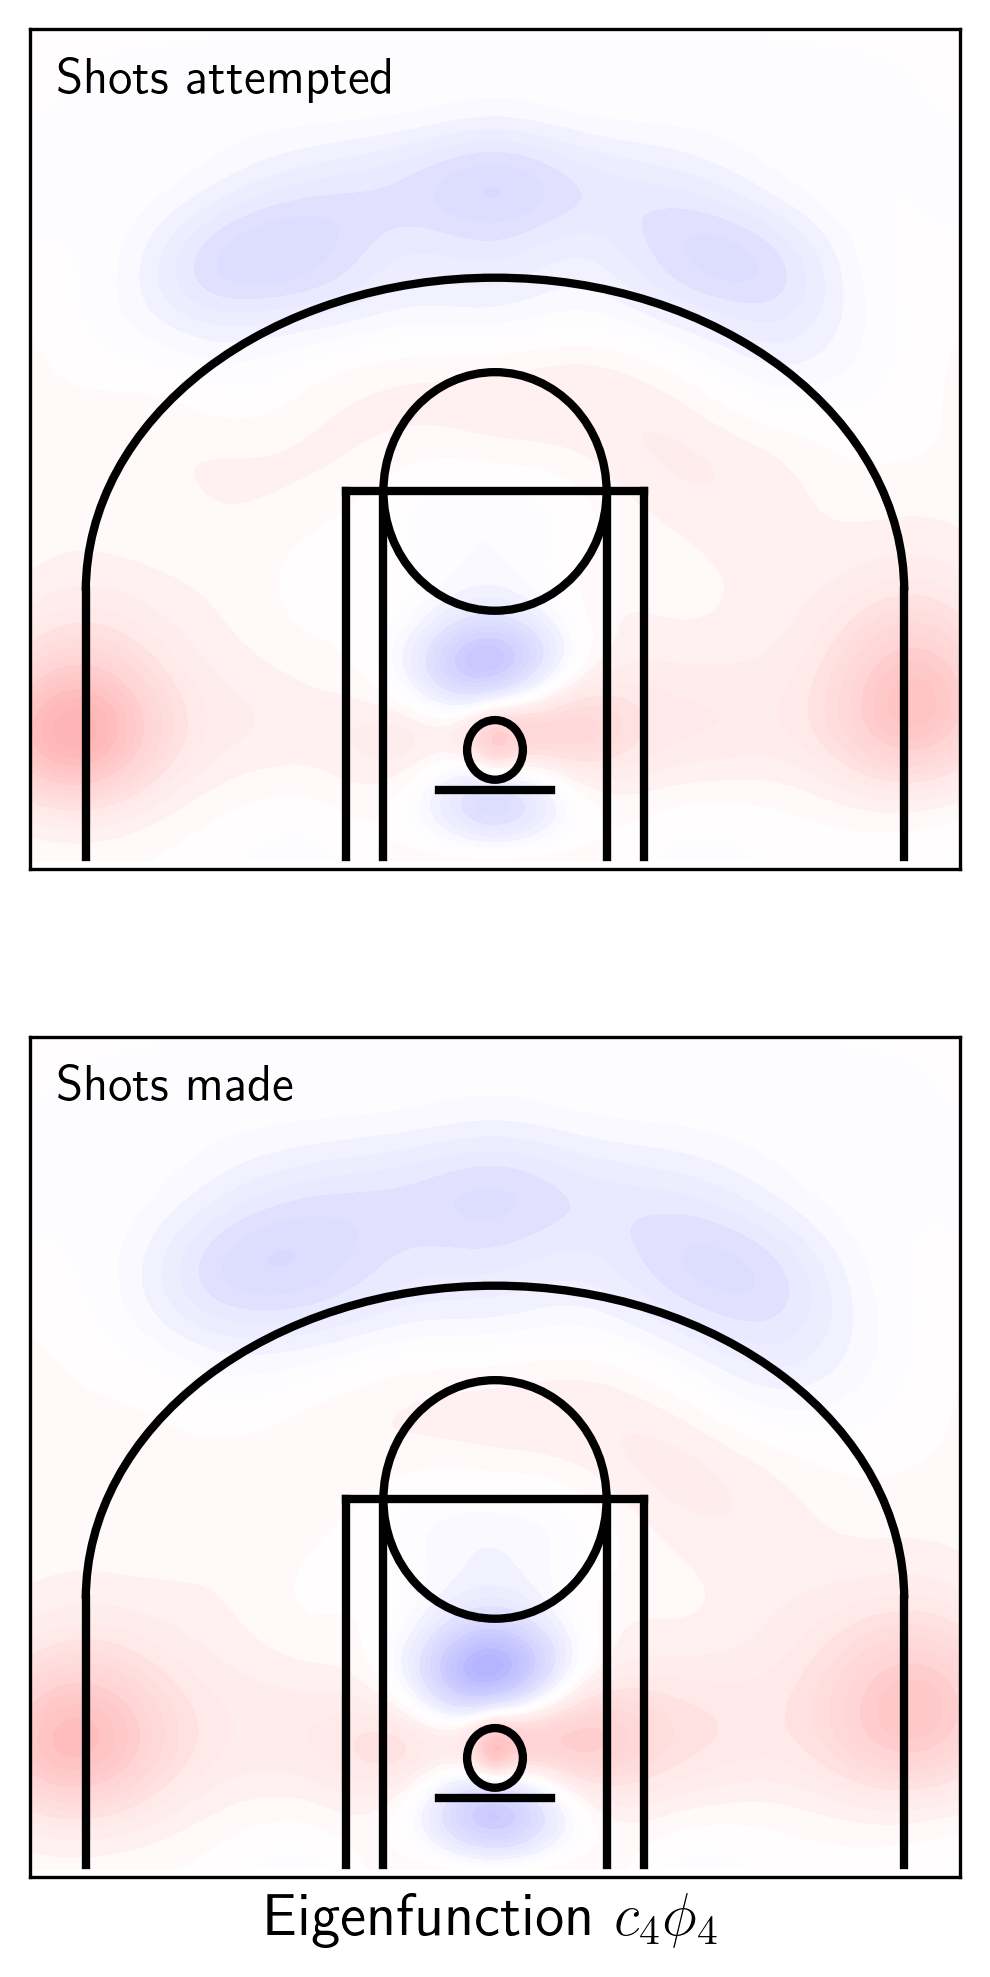

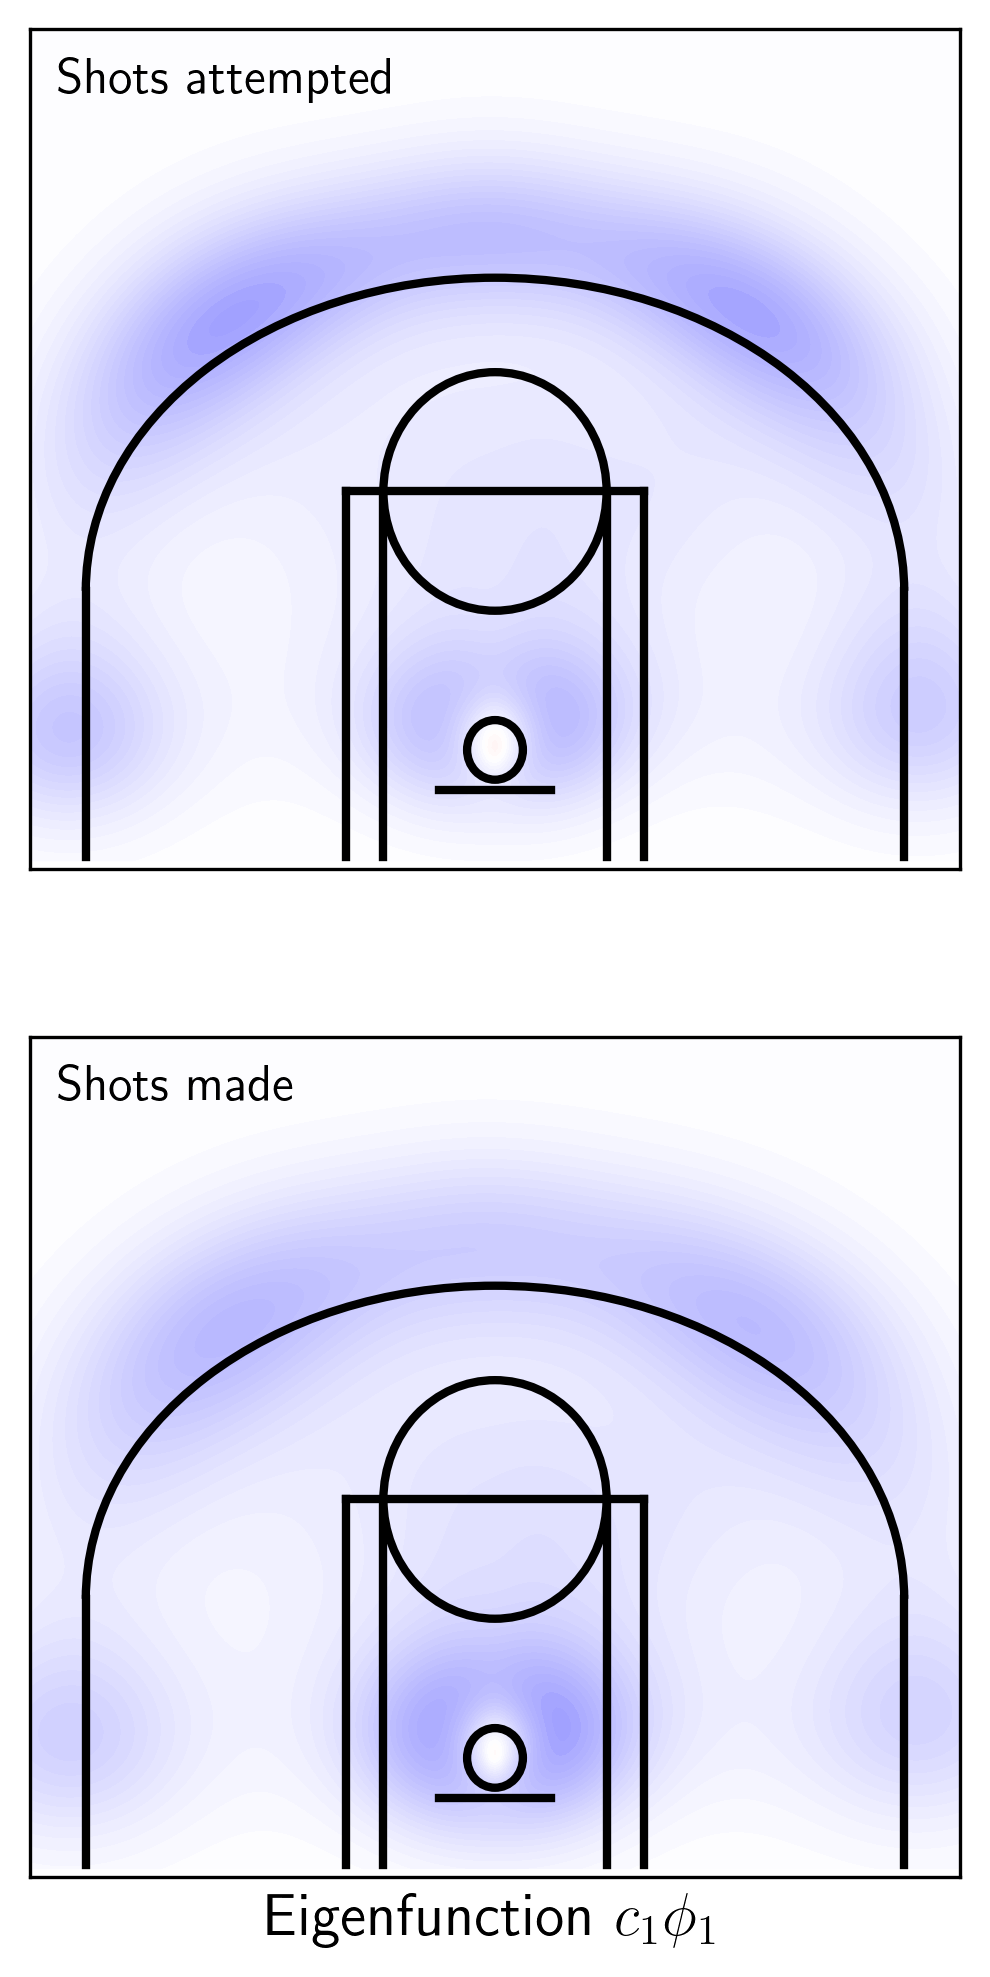

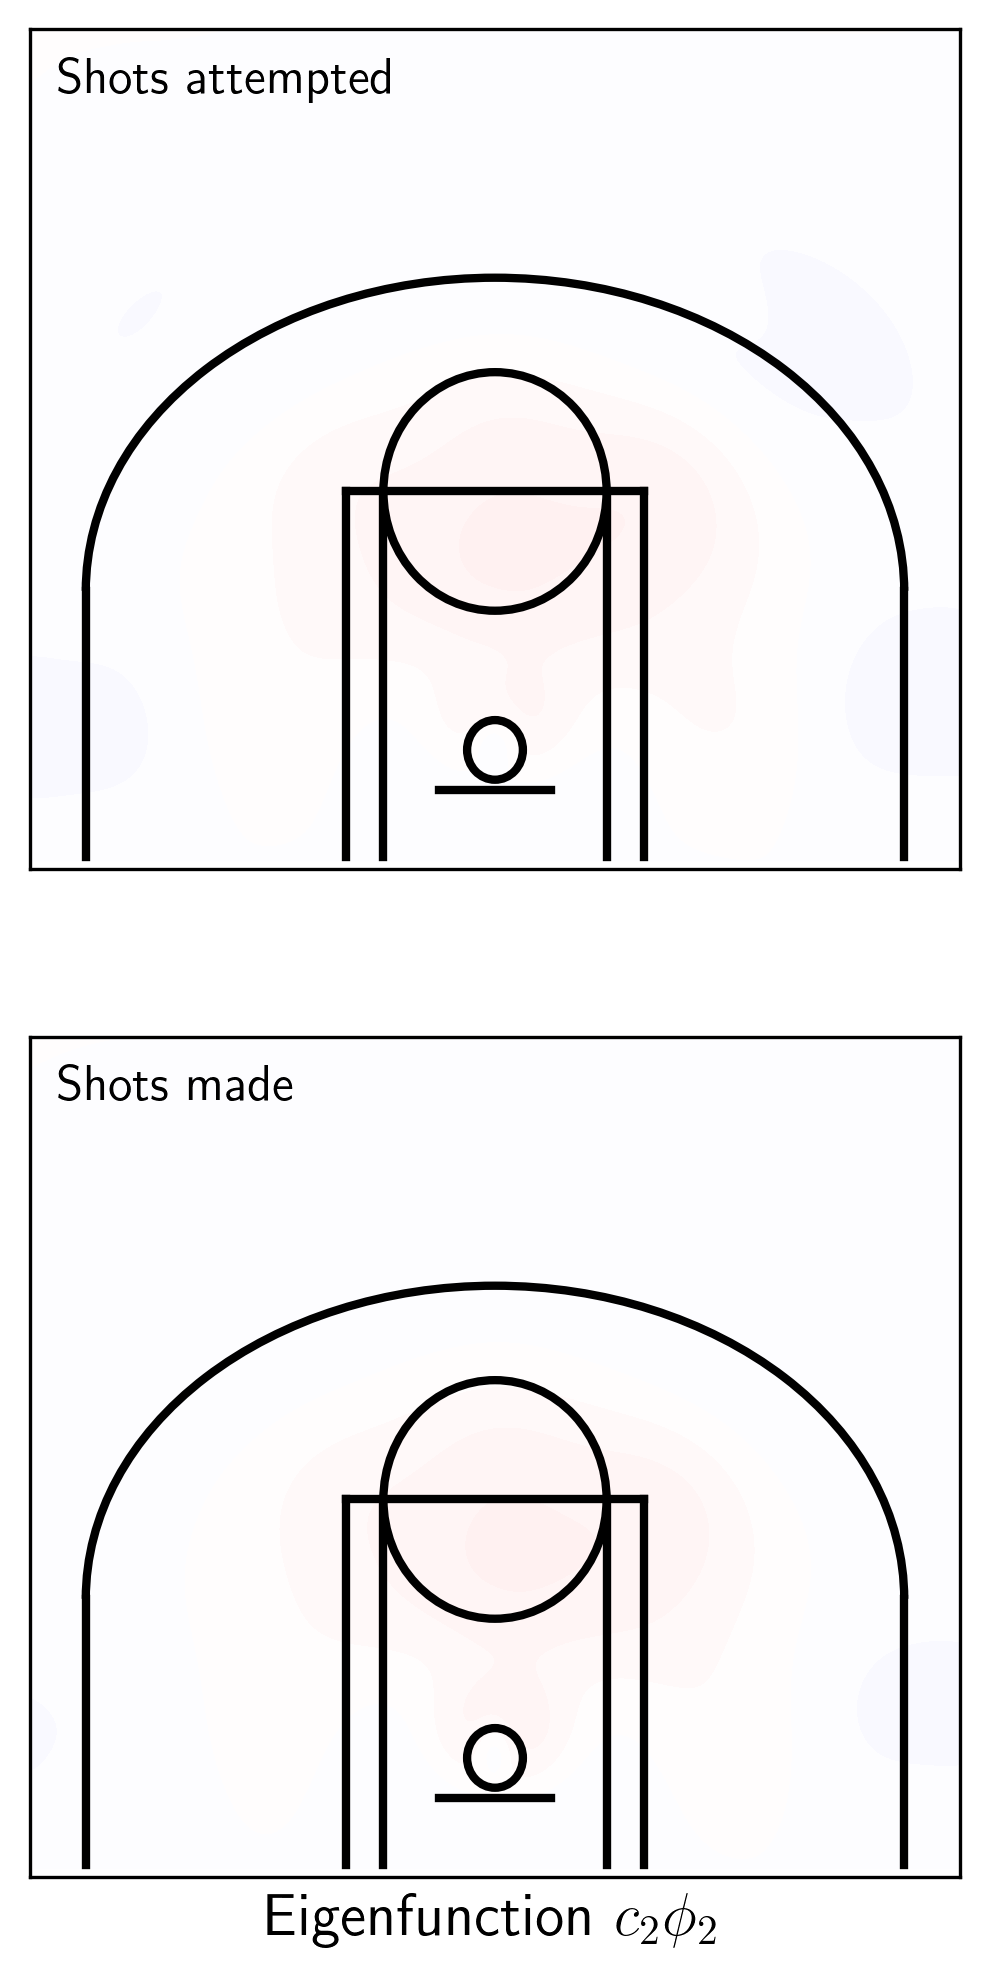

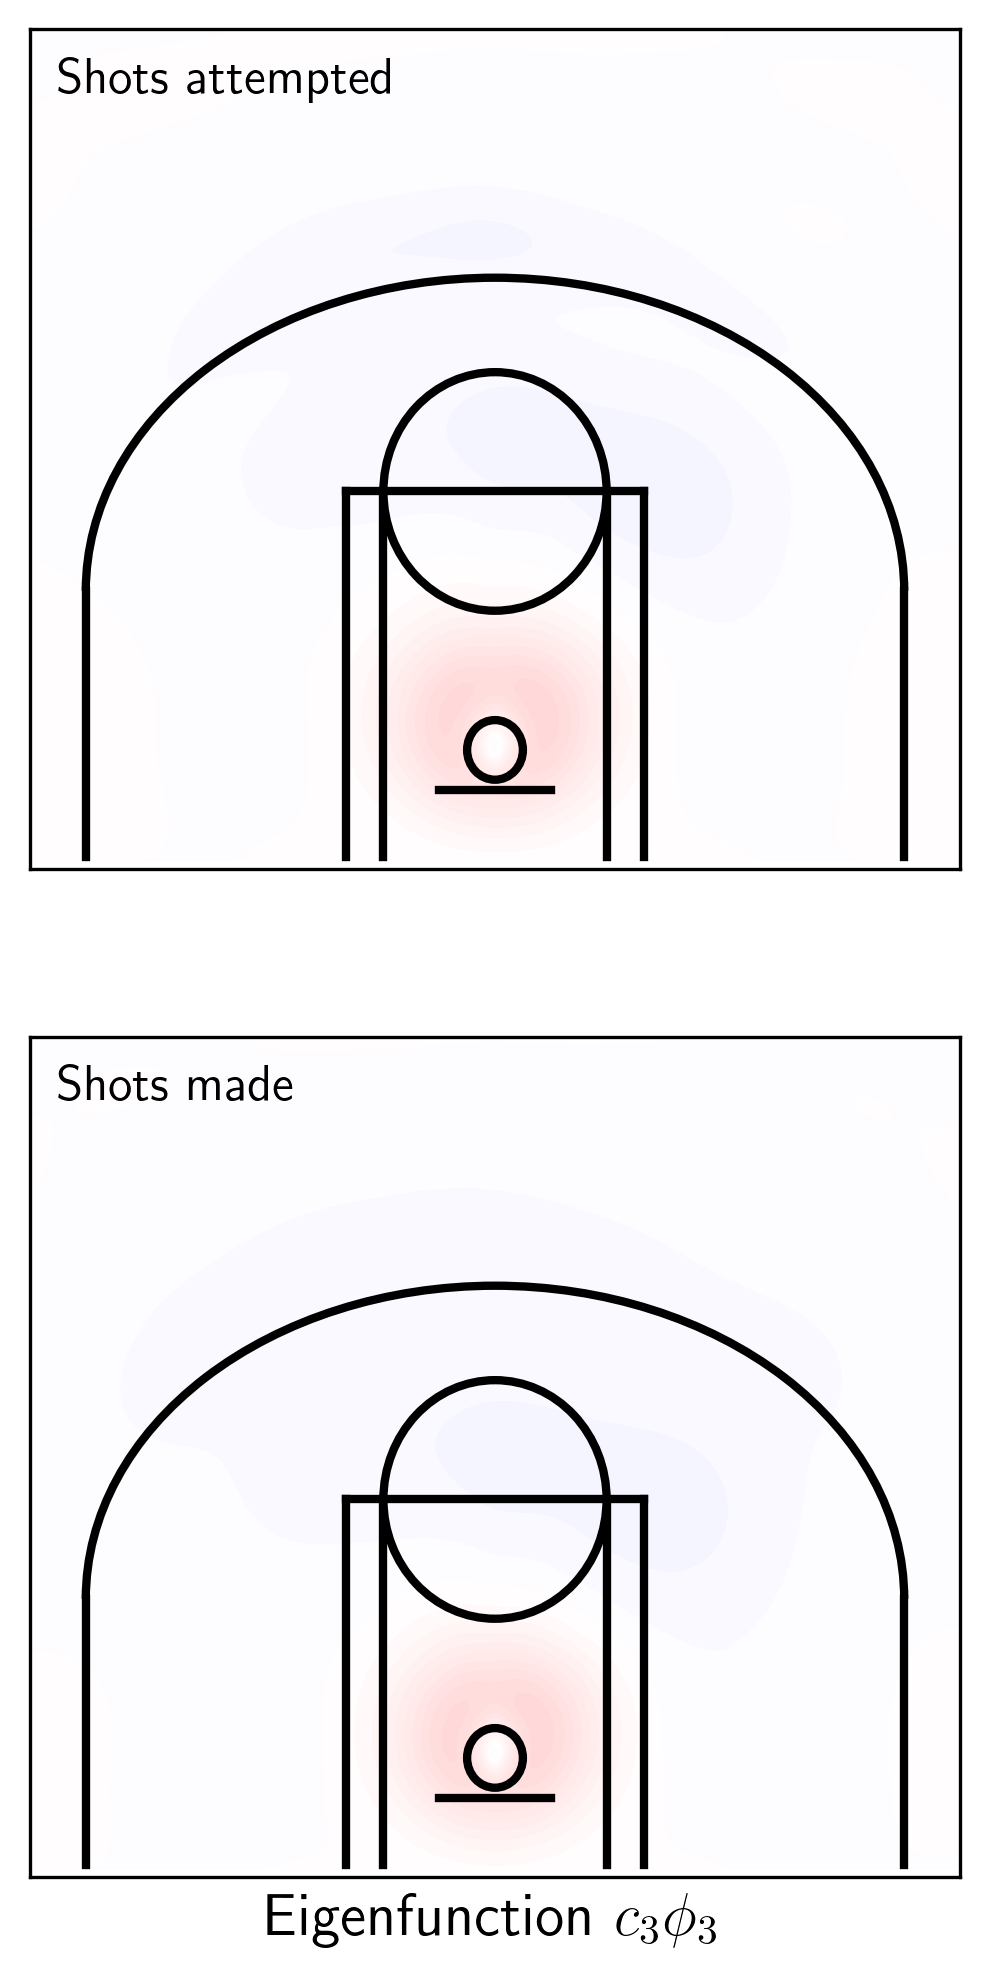

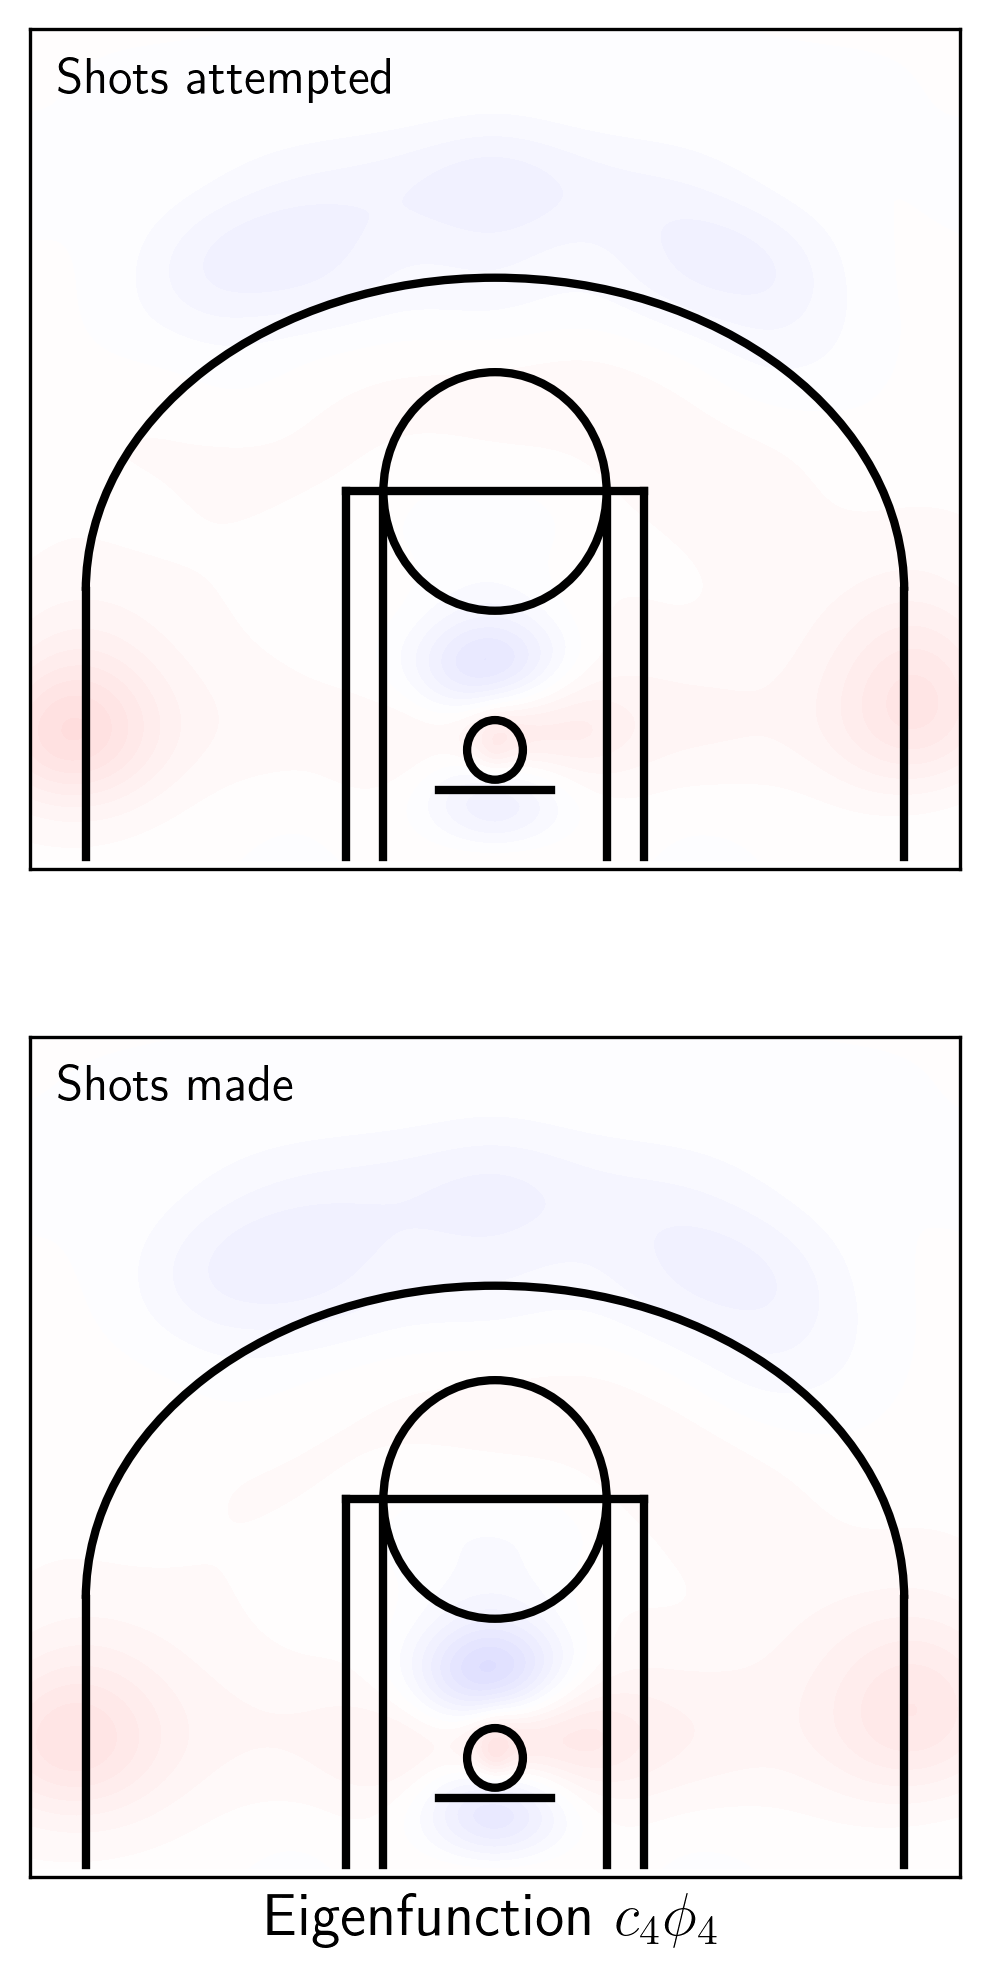

In [16]:
# Decomposition cluster 1
for c in range(5):
    for idx in range(4):
        fig, ax = plt.subplots(
            2, 1,
            figsize=(4, 8),
            facecolor='white',
            edgecolor='black',
            dpi=300
        )
        maxi = [np.max(np.abs(
            np.einsum('i, jk -> ijk', scores[idx].values, mfpca.eigenfunctions.data[pp][idx].values.squeeze())
        )) for pp in range(2)]

        ax[0] = ShotCharts.shots_decomposition_cluster(
            ax[0], mfpca, clustering['centers'][c, idx], idx, 0, 'Shots attempted', maxi[0]
        )
        ax[1] = ShotCharts.shots_decomposition_cluster(
            ax[1], mfpca, clustering['centers'][c, idx], idx, 1, 'Shots made', maxi[1]
        )
        ax[1].set_xlabel(f"Eigenfunction $c_{{{idx + 1}}}\phi_{{{idx + 1}}}$", fontsize='x-large')
    
        plt.savefig(f'./figures/cluster_{c + 1}_eigenfunction_{idx + 1}.eps', transparent=True, format='eps')
        plt.show()

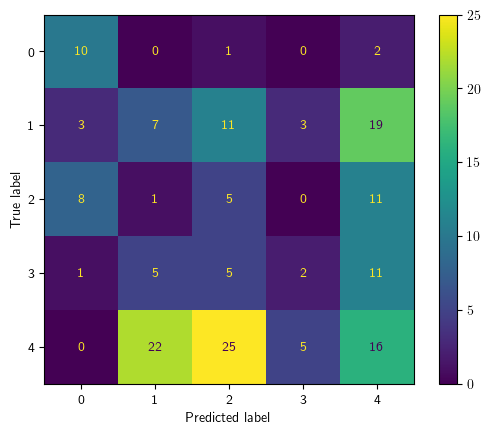

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    scores['POSITION_'].astype('category').cat.codes.values,
    scores['cluster']
)